# Volatility, Market Risk, and Real Option Valuation

Estimates GARCH volatility from daily returns, simulates a mixed
portfolio for VaR and expected shortfall under stochastic rates, reduces
the Treasury curve to principal components, and values abandonment and
expansion options on a trinomial tree.

| Section | Topic | Methods |
|---|---|---|
| 4.1 | Volatility estimation | GARCH(1,1) by maximum likelihood with normal and Student-t errors, volatility forecasts 30, 365, and 730 days out |
| 4.2 | Portfolio risk | Correlated stock and Vasicek rate simulation, Black-Scholes revaluation of a long-dated put, mean, VaR, and expected shortfall |
| 4.3 | Yield curve factors | PCA on monthly Treasury changes in three specifications, variance explained, 2-sigma PC1 confidence bands at 1 and 12 months |
| 4.4 | Real options | Trinomial tree for a mean-reverting log price calibrated to futures, abandonment and expansion valued by backward induction |

Reads data/Data.xlsx: 7,682 daily prices plus monthly Treasury rates
from 1953 to 2022. Everything else is set inline.

**Imports:**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from arch import arch_model
from scipy.optimize import minimize, differential_evolution
from mpl_toolkits.mplot3d import Axes3D

from scipy.stats import norm, beta
from scipy.optimize import minimize
from scipy.optimize import fsolve
from sklearn.decomposition import PCA
from IPython.display import Markdown
from scipy.optimize import brentq
plt.rcdefaults()

### Load Data

data/Data.xlsx supplies both datasets used below: sheet Return holds daily prices with precomputed returns for the GARCH estimation, and sheet UST holds month-end US Treasury rates across ten maturities for the PCA. Both series are plotted as loaded.

df_return: 7682 daily prices, 7681 returns


,Days,Price,Return
0,1,353.40,NaN
1,2,359.69,0.017799
2,3,358.76,-0.002586
3,4,355.67,-0.008613
4,5,352.20,-0.009756
...,...,...,...
7677,7678,2826.15,0.008162
7678,7679,2843.49,0.006136
7679,7680,2873.34,0.010498
7680,7681,2886.73,0.004660


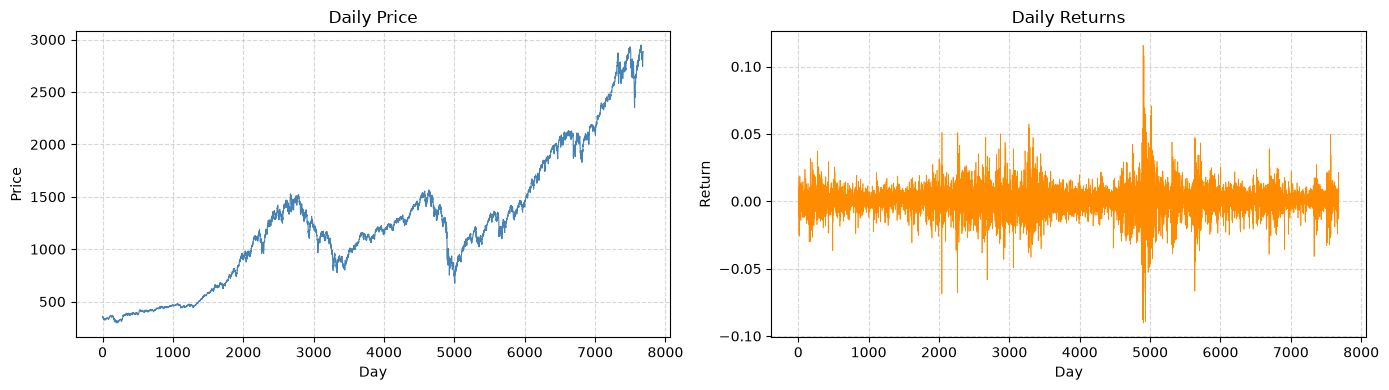

df_ust: 826 observations, 1953-04 to 2022-01


,Month,Date,3M,6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
0,1,1953-04-30,0.0219,0.0226,0.0236,0.0241,0.0251,0.0262,0.0273,0.0283,0.0308,0.0309
1,2,1953-05-29,0.0216,0.0228,0.0248,0.0258,0.0272,0.0287,0.0301,0.0305,0.0318,0.0319
2,3,1953-06-30,0.0211,0.0224,0.0245,0.0260,0.0274,0.0294,0.0306,0.0311,0.0321,0.0322
3,4,1953-07-31,0.0204,0.0218,0.0238,0.0246,0.0262,0.0275,0.0290,0.0293,0.0312,0.0313
4,5,1953-08-31,0.0204,0.0213,0.0228,0.0244,0.0258,0.0280,0.0290,0.0295,0.0310,0.0311
...,...,...,...,...,...,...,...,...,...,...,...,...
821,822,2021-09-30,0.0004,0.0005,0.0009,0.0028,0.0053,0.0098,0.0132,0.0152,0.0202,0.0208
822,823,2021-10-29,0.0005,0.0007,0.0015,0.0048,0.0075,0.0118,0.0144,0.0155,0.0198,0.0193
823,824,2021-11-30,0.0005,0.0010,0.0024,0.0052,0.0081,0.0114,0.0136,0.0143,0.0185,0.0178
824,825,2021-12-31,0.0006,0.0019,0.0039,0.0073,0.0097,0.0126,0.0144,0.0152,0.0194,0.0190


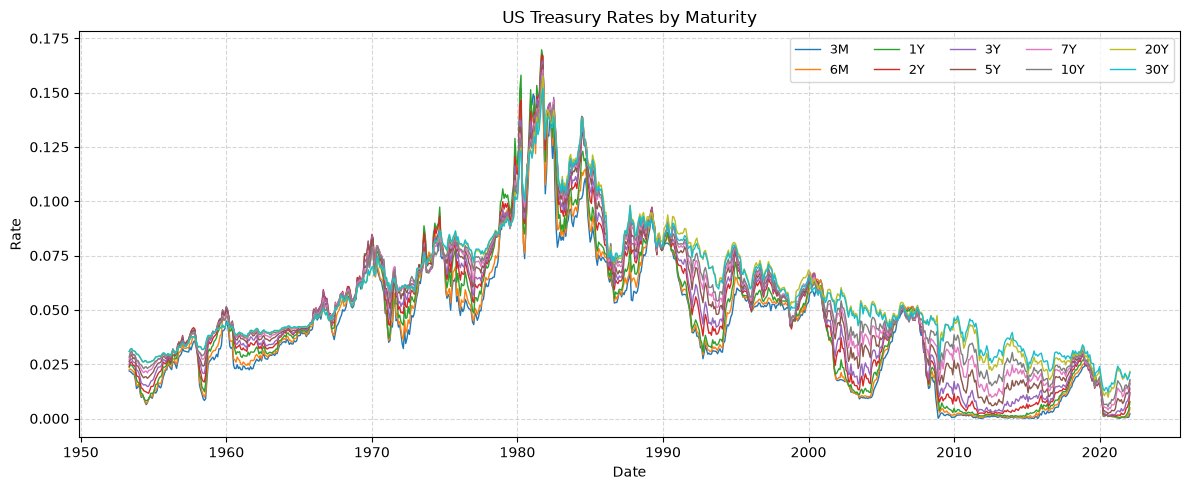

In [2]:
data_file = 'data/Data.xlsx'
df_return = pd.read_excel(data_file, sheet_name='Return', header=2, usecols=[0, 1, 2])
df_return.columns = ['Days', 'Price', 'Return']
print(f"df_return: {df_return.shape[0]} daily prices, "
      f"{df_return['Return'].notna().sum()} returns")
display(df_return)

plt.rcdefaults()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(df_return['Days'], df_return['Price'], color='steelblue', linewidth=0.8)
axes[0].set_title('Daily Price')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Price')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[1].plot(df_return['Days'], df_return['Return'], color='darkorange', linewidth=0.5)
axes[1].set_title('Daily Returns')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Return')
axes[1].grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


df_ust = pd.read_excel(data_file, sheet_name='UST', header=1, usecols=list(range(12)))
df_ust.columns = ['Date_serial', 'blank', '3M', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y']
df_ust = df_ust.drop(columns='blank')
df_ust['Date'] = pd.to_datetime(df_ust['Date_serial'], origin='1899-12-30', unit='D')
df_ust = df_ust.drop(columns='Date_serial')
df_ust = df_ust.sort_values('Date').reset_index(drop=True)
df_ust.insert(0, 'Month', np.arange(1, len(df_ust) + 1))

maturity_cols = ['3M', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y']
df_ust = df_ust[['Month', 'Date'] + maturity_cols]
print(f"df_ust: {df_ust.shape[0]} observations, "
      f"{df_ust['Date'].min().strftime('%Y-%m')} to {df_ust['Date'].max().strftime('%Y-%m')}")
display(df_ust)


fig, ax = plt.subplots(figsize=(12, 5))

for col in maturity_cols:
    ax.plot(df_ust['Date'], df_ust[col], linewidth=1.0, label=col)

ax.set_title('US Treasury Rates by Maturity')
ax.set_xlabel('Date')
ax.set_ylabel('Rate')
ax.legend(ncol=5, fontsize=9, loc='upper right')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## 4.1 Estimate the GARCH(1,1) parameters for the daily stock data

#### GARCH(1,1) Model

The conditional variance at observation $n$ is updated recursively:
$$
\sigma_n^2 = \omega + \alpha\,u_{n-1}^2 + \beta\,\sigma_{n-1}^2
$$

Variance-targeting form, with long-run variance $V_L$:
$$
\sigma_n^2 = \gamma V_L + \alpha\,u_{n-1}^2 + \beta\,\sigma_{n-1}^2,
\qquad \omega = \gamma V_L,
\qquad \gamma = 1-\alpha-\beta,
\qquad V_L = \frac{\omega}{1-\alpha-\beta}
$$

Stationarity constraints: $\quad \alpha \ge 0,\ \beta \ge 0,\ \gamma \ge 0,\ \alpha+\beta<1$.

#### Estimation Problem

**Parameters to estimate:** the vector $\theta = (\omega, \alpha, \beta)$. The derived quantities $\gamma = 1-\alpha-\beta$ and $V_L = \omega/\gamma$ follow directly.

**Data usage:** all $m = 7{,}681$ daily returns $\{u_i\}_{i=1}^{m}$ enter the likelihoo, no train/test split. Maximum likelihood consumes the full series. The mean of $u$ is assumed zero, a standard simplification for daily equity returns.

**Recursion seed:** the GARCH recursion needs a starting variance. We initialize with the first squared shock,
$$
v_1 = u_1^2,
$$
so that valid likelihood terms run from $i = 2$ to $i = m$, giving $m - 1$ contributions to the objective.

**Per-observation log-likelihood (Normal errors)**, with constants dropped:
$$
\ell_i(\theta) = -\ln v_i(\theta) - \frac{u_i^2}{v_i(\theta)},
\qquad v_i(\theta) = \omega + \alpha\,u_{i-1}^2 + \beta\,v_{i-1}(\theta)
$$

**Optimization problem:**
$$
\hat\theta = \arg\max_{\omega,\alpha,\beta}\ \sum_{i=2}^{m}\ell_i(\theta)
\qquad\text{s.t.}\qquad
\omega>0,\ \alpha\ge 0,\ \beta\ge 0,\ \alpha+\beta<1
$$

This is a non-linear constrained maximization in three variables. Each evaluation of the objective rebuilds the entire variance path $\{v_i\}_{i=2}^{m}$ by forward recursion, so every term in the sum depends on $\theta$.

#### Forecasting Future Volatility

Once $\hat\theta$ is fitted, the expected variance $t$ days ahead decays geometrically toward $V_L$:
$$
E\!\left[\sigma_{n+t}^2\right] = V_L + (\alpha + \beta)^t\,\big(\sigma_n^2 - V_L\big)
$$
where $\sigma_n^2 = v_m$ is the last in-sample conditional variance. Daily volatility forecast at horizon $t$:
$$
\hat\sigma_{n+t} = \sqrt{E[\sigma_{n+t}^2]}
$$

### a) What are the GARCH parameters and the forecasted volatilities 30, 365, and 730 days into the future?

omega = 1.293766e-06
alpha = 0.082774
beta = 0.905224
gamma = 0.012002
V_L = 1.077978e-04
sqrt(V_L) = 0.010383
Annualized Long-Run Vol = 16.4818%
Log-likelihood = 64932.3745


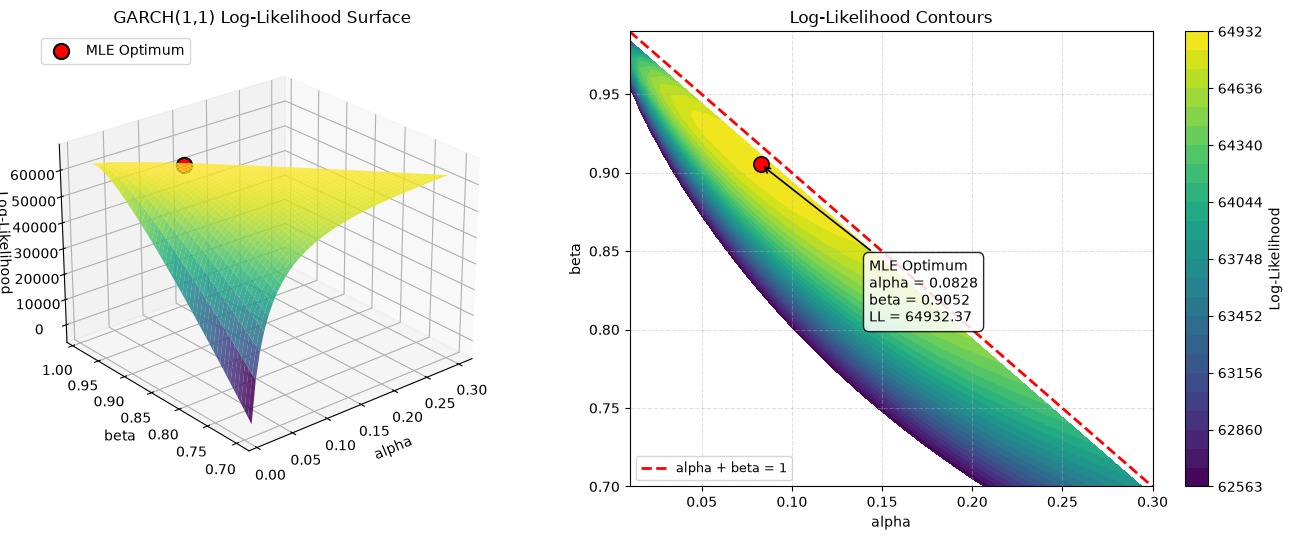

In [3]:
u = df_return['Return'].dropna().to_numpy()
m = len(u)

# Variance path under GARCH(1,1)
def garch_var_path(omega, alpha, beta, u):
    m = len(u)
    v = np.empty(m)
    v[0] = u[0]**2
    for t in range(1, m):
        v[t] = omega + alpha * u[t-1]**2 + beta * v[t-1]
    return v

# Negative log-likelihood (omega scaled by 1e-6)
def neg_log_likelihood(params, u):
    omega_s, alpha, beta = params
    omega = omega_s * 1e-6
    if alpha + beta >= 0.9999 or omega <= 0:
        return 1e10
    v = garch_var_path(omega, alpha, beta, u)
    return -np.sum(-np.log(v[1:]) - u[1:]**2 / v[1:])

x0 = [1.0, 0.10, 0.85]
bounds = [(1e-4, 100.0), (1e-6, 0.5), (0.5, 0.999)]
constraints = [{'type': 'ineq', 'fun': lambda p: 0.9999 - p[1] - p[2]}]

result = minimize(neg_log_likelihood, x0, args=(u,), method='SLSQP',bounds=bounds, constraints=constraints, options={'ftol': 1e-15, 'maxiter': 1000})

omega_s, alpha, beta = result.x
omega = omega_s * 1e-6
gamma = 1 - alpha - beta
V_L = omega / gamma
log_lik = -result.fun

print(f"omega = {omega:.6e}")
print(f"alpha = {alpha:.6f}")
print(f"beta = {beta:.6f}")
print(f"gamma = {gamma:.6f}")
print(f"V_L = {V_L:.6e}")
print(f"sqrt(V_L) = {np.sqrt(V_L):.6f}")
print(f"Annualized Long-Run Vol = {np.sqrt(252*V_L):.4%}")
print(f"Log-likelihood = {log_lik:.4f}")

n_grid = 50
alpha_values = np.linspace(0.01, 0.30, n_grid)
beta_values = np.linspace(0.70, 0.99, n_grid)
A_grid, B_grid = np.meshgrid(alpha_values, beta_values)
LL_grid = np.zeros((n_grid, n_grid))
for i in range(n_grid):
    for j in range(n_grid):
        a = A_grid[i, j]
        b = B_grid[i, j]
        if a + b < 0.9999:
            LL_grid[i, j] = -neg_log_likelihood([omega * 1e6, a, b], u)
        else:
            LL_grid[i, j] = np.nan

plt.rcdefaults()
fig = plt.figure(figsize=(14, 5.5))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(A_grid, B_grid, LL_grid, cmap='viridis', alpha=0.85)
ax1.scatter(alpha, beta, log_lik, color='red', s=120, edgecolor='black', linewidth=1.5, label='MLE Optimum')
ax1.set_xlabel('alpha')
ax1.set_ylabel('beta')
ax1.set_zlabel('Log-Likelihood')
ax1.set_title('GARCH(1,1) Log-Likelihood Surface')
ax1.view_init(elev=25, azim=-130)
ax1.legend(loc='upper left')


ax2 = fig.add_subplot(1, 2, 2)
levels = np.linspace(np.nanpercentile(LL_grid, 50), np.nanmax(LL_grid), 25)
contour_fill = ax2.contourf(A_grid, B_grid, LL_grid, levels=levels, cmap='viridis')
ax2.contour(A_grid, B_grid, LL_grid, levels=12, colors='white',linewidths=0.5, alpha=0.6)
ax2.plot(alpha_values, 0.9999 - alpha_values, color='red', linestyle='--', linewidth=2, label='alpha + beta = 1')
ax2.plot(alpha, beta, marker='.', markersize=22, color='red', markeredgecolor='black', markeredgewidth=1.2)
ax2.annotate(
    f'MLE Optimum\nalpha = {alpha:.4f}\nbeta = {beta:.4f}\nLL = {log_lik:.2f}',
    xy=(alpha, beta),
    xytext=(alpha + 0.06, beta - 0.10),
    fontsize=10,
    bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='black', alpha=0.85),
    arrowprops=dict(arrowstyle='->', color='black', lw=1.2))

ax2.set_xlabel('alpha')
ax2.set_ylabel('beta')
ax2.set_xlim(0.01, 0.30)
ax2.set_ylim(0.70, 0.99)
ax2.set_title('Log-Likelihood Contours')
ax2.grid(True, linestyle='--', alpha=0.4)
ax2.legend(loc='lower left', fontsize=9)
plt.colorbar(contour_fill, ax=ax2, label='Log-Likelihood')
plt.tight_layout()
plt.show()

Horizon (days),E[var],Daily Vol,Annualized Vol
30,9.4343e-05,0.0097,15.4189%
365,1.0756e-04,0.0104,16.4638%
730,1.0779e-04,0.0104,16.4816%


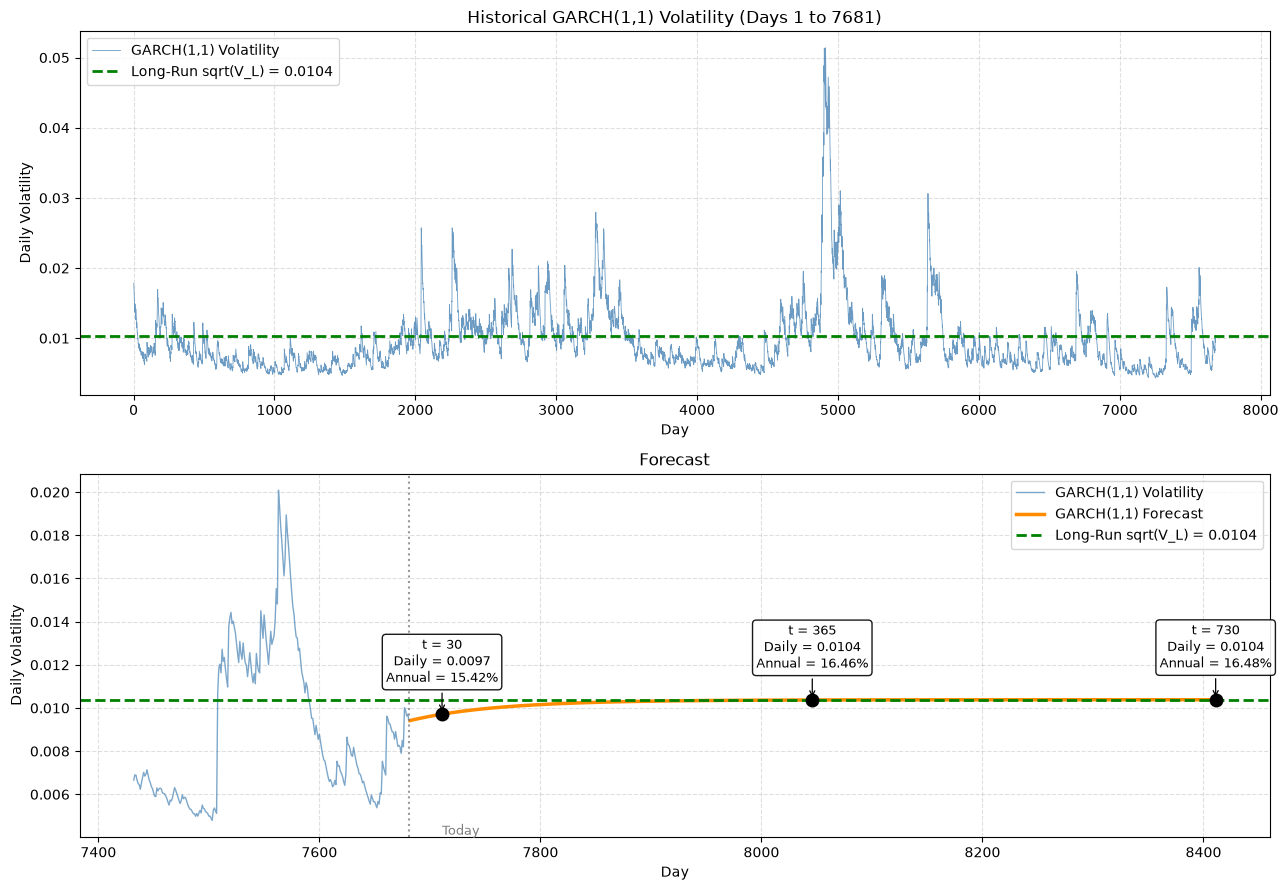

In [4]:
v_path = garch_var_path(omega, alpha, beta, u)
v_last = v_path[-1]
persistence = alpha + beta
forecast_rows = []

for t in [30, 365, 730]:
    var_t = V_L + persistence**t * (v_last - V_L)
    forecast_rows.append({
        'Horizon (days)': t,
        'E[var]':         var_t,
        'Daily Vol':      np.sqrt(var_t),
        'Annualized Vol': np.sqrt(252 * var_t)})

df_forecast = pd.DataFrame(forecast_rows)
df_forecast = df_forecast.style.format({ 'E[var]': '{:.4e}','Daily Vol': '{:.4f}', 'Annualized Vol': '{:.4%}'})

display(df_forecast.hide(axis='index'))

sqrt_VL = np.sqrt(V_L)
historical_vol = np.sqrt(v_path)
historical_days = np.arange(1, m + 1)
forecast_horizons = np.arange(1, 731)
forecast_vol = np.sqrt(V_L + persistence**forecast_horizons * (v_last - V_L))
forecast_days = m + forecast_horizons

key_horizons = [30, 365, 730]
key_days = [m + t for t in key_horizons]
key_vols = [np.sqrt(V_L + persistence**t * (v_last - V_L)) for t in key_horizons]


fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(13, 9))

# === Top: full historical GARCH(1,1) volatility ===
ax_top.plot(historical_days, historical_vol, color='steelblue',
            linewidth=0.6, alpha=0.8, label='GARCH(1,1) Volatility')
ax_top.axhline(sqrt_VL, color='green', linestyle='--', linewidth=2,
               label=f'Long-Run sqrt(V_L) = {sqrt_VL:.4f}')
ax_top.set_xlabel('Day')
ax_top.set_ylabel('Daily Volatility')
ax_top.set_title(f'Historical GARCH(1,1) Volatility (Days 1 to {m})')
ax_top.grid(True, linestyle='--', alpha=0.4)
ax_top.legend(loc='upper left')


zoom_start = m - 250
ax_bot.plot(historical_days[zoom_start:], historical_vol[zoom_start:], color='steelblue', linewidth=1.0, alpha=0.7, label='GARCH(1,1) Volatility')
ax_bot.plot(forecast_days, forecast_vol, color='darkorange', linewidth=2.5, label='GARCH(1,1) Forecast')
ax_bot.axhline(sqrt_VL, color='green', linestyle='--', linewidth=2, label=f'Long-Run sqrt(V_L) = {sqrt_VL:.4f}')
ax_bot.axvline(m, color='gray', linestyle=':', linewidth=1.5, alpha=0.8)
ax_bot.text(m + 30, ax_bot.get_ylim()[0] + 0.0001, 'Today', fontsize=9, color='gray')

for t, day, vol in zip(key_horizons, key_days, key_vols):
    ax_bot.plot(day, vol, marker='o', markersize=9, color='black', zorder=5)
    ax_bot.annotate(
        f't = {t}\nDaily = {vol:.4f}\nAnnual = {vol*np.sqrt(252):.2%}',
        xy=(day, vol), xytext=(day, vol + 0.0015),
        fontsize=9, ha='center',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='black', alpha=0.9),
        arrowprops=dict(arrowstyle='->', color='black', lw=0.9))

ax_bot.set_xlabel('Day')
ax_bot.set_ylabel('Daily Volatility')
ax_bot.set_title('Forecast')
ax_bot.grid(True, linestyle='--', alpha=0.4)
ax_bot.legend(loc='upper right')

plt.tight_layout()
plt.show()

### b) GARCH(1,1) parameters under Student-t innovations

The variance recursion and forecast formula are unchanged from part (a). We modify only the innovation distribution: $\varepsilon_i = u_i/\sqrt{v_i}$ now follows a scaled Student-t with $f$ degrees of freedom, rescaled by $\sqrt{(f-2)/f}$ so that $\operatorname{Var}(\varepsilon_i) = 1$ — keeping the GARCH recursion self-consistent.

Per-observation log-likelihood:
$$
\ell_i(\omega,\alpha,\beta,f) = \ln\Gamma\!\left(\tfrac{f+1}{2}\right) - \ln\Gamma\!\left(\tfrac{f}{2}\right) - \tfrac{1}{2}\ln\!\big(\pi(f-2)\,v_i\big) - \tfrac{f+1}{2}\,\ln\!\left(1 + \frac{u_i^2}{(f-2)\,v_i}\right)
$$

The optimization adds $f$ as a fourth parameter:
$$
\hat\theta = \arg\max_{\omega,\,\alpha,\,\beta,\,f}\ \sum_{i=2}^{m}\ell_i(\omega,\alpha,\beta,f)
\qquad\text{s.t.}\qquad
\omega > 0,\ \alpha \ge 0,\ \beta \ge 0,\ \alpha+\beta < 1,\ f > 2
$$



omega = 6.684792e-07
alpha = 0.077026
beta = 0.921236
gamma = 0.001738
f = 5.463351
V_L = 3.847284e-04
sqrt(V_L) = 0.019614
Annualized Long-Run Vol = 31.1370%


Horizon (days),E[var],Daily Vol,Annualized Vol
30,1.0451e-04,0.0102,16.2289%
365,2.2824e-04,0.0151,23.9827%
730,3.0178e-04,0.0174,27.5769%


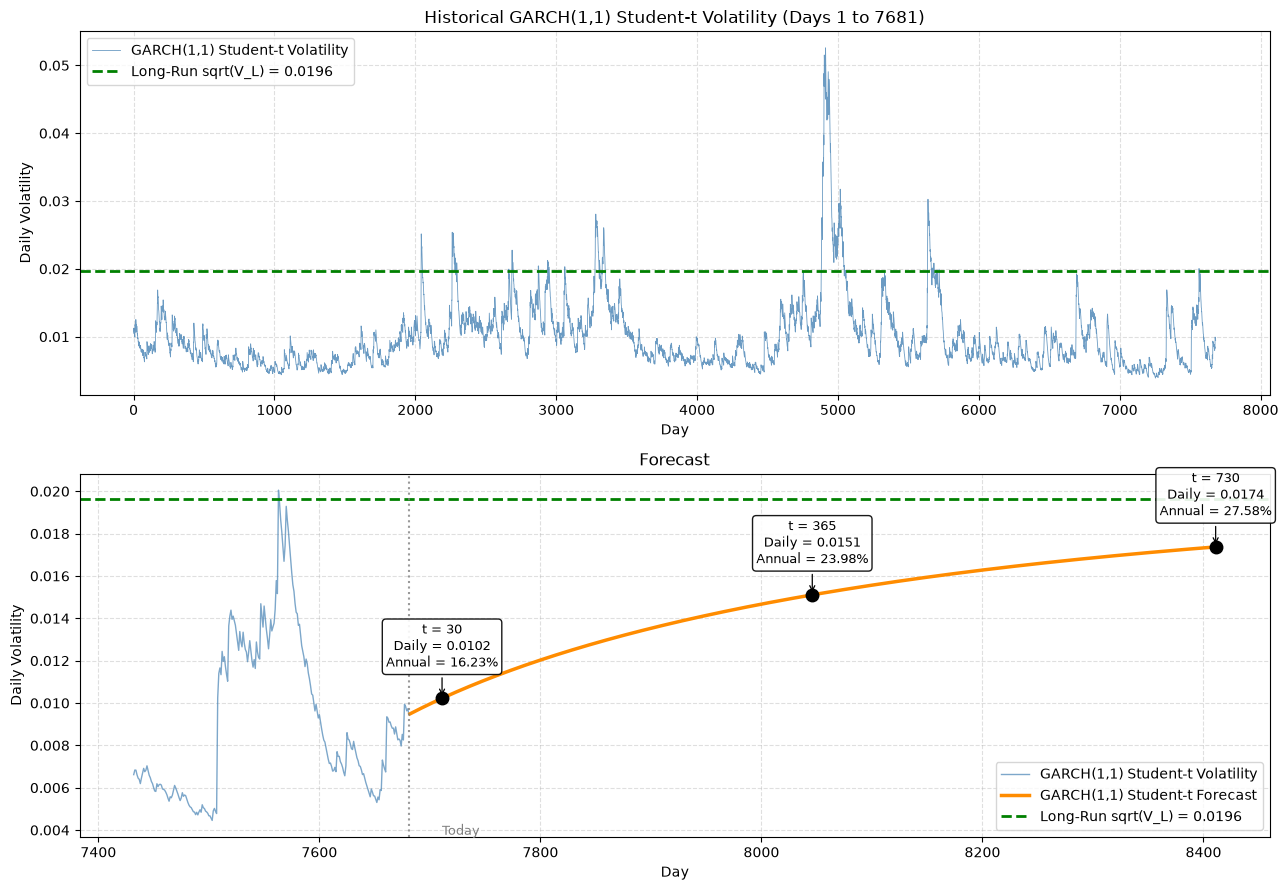

In [5]:
scaled_returns = u * 100
model_t = arch_model(scaled_returns, mean='Zero', vol='GARCH', p=1, q=1, dist='t', rescale=False)
res_t = model_t.fit(disp='off', show_warning=False, tol=1e-12, options={'maxiter': 2000},cov_type='robust')

omega_t = res_t.params['omega']/10000
alpha_t = res_t.params['alpha[1]']
beta_t = res_t.params['beta[1]']
f_t = res_t.params['nu']
gamma_t = 1 - alpha_t - beta_t
V_L_t = omega_t / gamma_t

cond_vol_t = np.asarray(res_t.conditional_volatility)/100
v_path_t = cond_vol_t ** 2
v_last_t = v_path_t[-1]
persistence_t = alpha_t + beta_t

print(f"omega = {omega_t:.6e}")
print(f"alpha = {alpha_t:.6f}")
print(f"beta = {beta_t:.6f}")
print(f"gamma = {gamma_t:.6f}")
print(f"f = {f_t:.6f}")
print(f"V_L = {V_L_t:.6e}")
print(f"sqrt(V_L) = {np.sqrt(V_L_t):.6f}")
print(f"Annualized Long-Run Vol = {np.sqrt(252*V_L_t):.4%}")

sqrt_VL_t = np.sqrt(V_L_t)
hist_vol_t = np.sqrt(v_path_t)
hist_days = np.arange(1, m + 1)

fc_horizons = np.arange(1, 731)
fc_var_t = V_L_t + persistence_t**fc_horizons * (v_last_t - V_L_t)
fc_vol_t = np.sqrt(fc_var_t)
fc_days = m + fc_horizons

key_horizons = [30, 365, 730]
key_idx = [t - 1 for t in key_horizons]
key_days = [m + t for t in key_horizons]
key_vols = fc_vol_t[key_idx]

forecast_rows_t = [
    {'Horizon (days)': t,
     'E[var]': fc_var_t[i],
     'Daily Vol': fc_vol_t[i],
     'Annualized Vol': np.sqrt(252) * fc_vol_t[i]}
    for t, i in zip(key_horizons, key_idx)]

df_forecast_t = pd.DataFrame(forecast_rows_t).style.format({
    'E[var]':'{:.4e}',
    'Daily Vol':'{:.4f}',
    'Annualized Vol':'{:.4%}',
})
display(df_forecast_t.hide(axis='index'))

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(13, 9))

ax_top.plot(hist_days, hist_vol_t, color='steelblue', linewidth=0.6, alpha=0.8, label='GARCH(1,1) Student-t Volatility')
ax_top.axhline(sqrt_VL_t, color='green', linestyle='--', linewidth=2,label=f'Long-Run sqrt(V_L) = {sqrt_VL_t:.4f}')
ax_top.set_xlabel('Day')
ax_top.set_ylabel('Daily Volatility')
ax_top.set_title(f'Historical GARCH(1,1) Student-t Volatility (Days 1 to {m})')
ax_top.grid(True, linestyle='--', alpha=0.4)
ax_top.legend(loc='upper left')

zoom_start = m - 250
ax_bot.plot(hist_days[zoom_start:], hist_vol_t[zoom_start:],color='steelblue', linewidth=1.0, alpha=0.7, label='GARCH(1,1) Student-t Volatility')
ax_bot.plot(fc_days, fc_vol_t, color='darkorange', linewidth=2.5,label='GARCH(1,1) Student-t Forecast')
ax_bot.axhline(sqrt_VL_t, color='green', linestyle='--', linewidth=2, label=f'Long-Run sqrt(V_L) = {sqrt_VL_t:.4f}')
ax_bot.axvline(m, color='gray', linestyle=':', linewidth=1.5, alpha=0.8)
ax_bot.text(m + 30, ax_bot.get_ylim()[0] + 0.0001, 'Today', fontsize=9, color='gray')
for t, day, vol in zip(key_horizons, key_days, key_vols):
    ax_bot.plot(day, vol, marker='o', markersize=9, color='black', zorder=5)
    ax_bot.annotate(f't = {t}\nDaily = {vol:.4f}\nAnnual = {vol*np.sqrt(252):.2%}',
        xy=(day, vol), xytext=(day, vol + 0.0015),
        fontsize=9, ha='center',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='black', alpha=0.9),
        arrowprops=dict(arrowstyle='->', color='black', lw=0.9))

ax_bot.set_xlabel('Day')
ax_bot.set_ylabel('Daily Volatility')
ax_bot.set_title('Forecast')
ax_bot.grid(True, linestyle='--', alpha=0.4)
ax_bot.legend(loc='lower right')

plt.tight_layout()
plt.show()

## 4.2 Portfolio Risk with Vasicek Rates and a Long-Dated Put

Initial portfolio at $t = 0$:
- 1 unit of stock with $S_0 = 100$
- $V_{MM,0} = 100$ in a money-market account earning the prevailing risk-free rate
- 1 long put option, 3-year maturity, strike $K = 80$
Market parameters:
| Quantity | Symbol | Value |
|---|---|---|
| Stock real-world drift | $\mu_{RW}$ | 8% |
| Stock real-world volatility | $\sigma_{RW}$ | 17% |
| Implied volatility (option pricing) | $\sigma_{IV}$ | 20% |
| Vasicek mean-reversion speed | $a$ | 0.1 |
| Vasicek long-run rate | $b$ | 0.03 |
| Vasicek volatility | $\sigma_r$ | 0.01 |
| Initial short rate | $r_0$ | 3% (flat term structure) |
| Stock-rate correlation | $\rho$ | 30% |
| Horizon | $T$ | 1 year |
| Time steps | — | 12 monthly, $\Delta t = 1/12$ |

#### Joint dynamics

Stock follows real-world GBM:
$$
S_{t+\Delta t} = S_t \exp\!\Big((\mu_{RW} - \tfrac{1}{2}\sigma_{RW}^2)\Delta t + \sigma_{RW}\sqrt{\Delta t}\,Z_S\Big)
$$

Short rate follows Vasicek; we use the exact transition (not Euler) for stability with a small $\sigma_r$:
$$
r_{t+\Delta t} = r_t e^{-a\Delta t} + b(1 - e^{-a\Delta t}) + \sqrt{\frac{\sigma_r^2(1 - e^{-2a\Delta t})}{2a}}\,Z_r
$$

Correlation of shocks via Cholesky of $\begin{pmatrix} 1 & \rho \\ \rho & 1\end{pmatrix}$:
$$
Z_r = \rho\,Z_S + \sqrt{1-\rho^2}\,U,\qquad Z_S, U \sim \mathcal{N}(0,1)\ \text{independent}
$$

Money-market growth uses the realized step rate:
$$
V_{MM,t+\Delta t} = V_{MM,t}\cdot e^{r_t \Delta t}
$$

#### Put valuation at $T = 1$

The put has 2 years remaining and is repriced under Black-Scholes with the simulated $S_T$ and $r_T$:
$$
P_T = K e^{-r_T \tau}\,\Phi(-d_2) - S_T\,\Phi(-d_1),\quad
d_{1,2} = \frac{\ln(S_T/K) + (r_T \pm \tfrac{1}{2}\sigma_{IV}^2)\tau}{\sigma_{IV}\sqrt{\tau}},\quad \tau = 2
$$

#### Portfolio terminal value

$$
V_T = S_T + V_{MM,T} + P_T
$$

#### Risk metrics over the simulated $V_T$ distribution

Mean, median, and standard deviation of $V_T$ are direct sample statistics. For VaR and Expected Shortfall at the 90% level we report the lower tail of $V_T$ (the "value-at-percentile" convention used in the spreadsheet reference):
$$
\text{VaR}_{90\%} = \text{quantile}(V_T,\ 0.1),\qquad
\text{ES}_{90\%} = \mathbb{E}\!\left[V_T \mid V_T \le \text{VaR}_{90\%}\right]
$$

We use $N = 10{,}000$ scenarios

### a) What is the mean, median, std dev, VaR (90%), and Expected Shortfall (90%) of this portfolio in 1 year?


Initial put value = 2.9262
Initial portfolio = 202.9262


Metric,Portfolio Value
Mean,213.276216
Median,210.720632
Std Dev,16.924810
VaR (90%),193.307351
ES (90%),189.569922


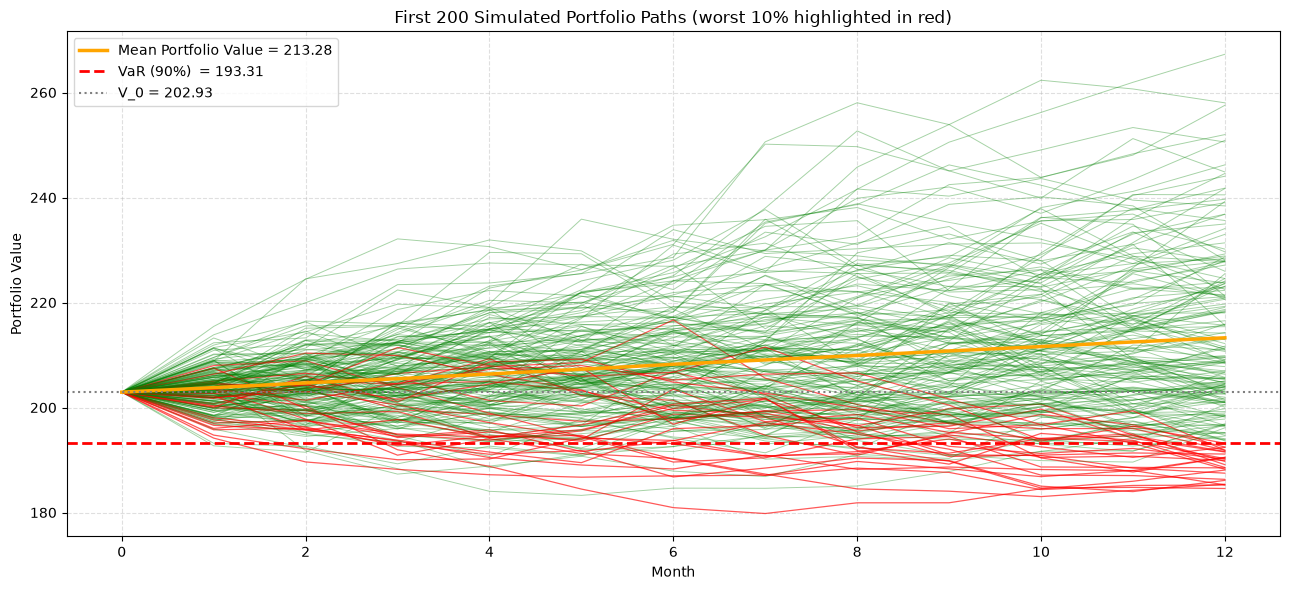

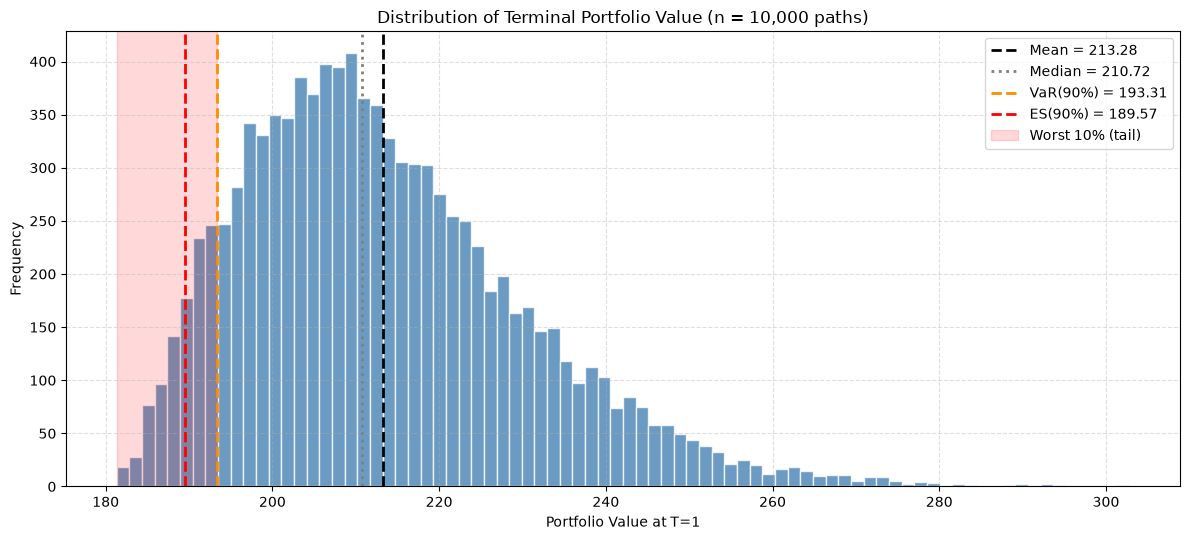

In [6]:
S0 = 100
MM0 = 100
K = 80
T_put = 3
T = 1
n_steps = 12
dt = T/n_steps
n_paths = 10000

mu_RW = 0.08
sigma_RW = 0.17
sigma_IV = 0.2
r0 = 0.03
a = 0.1
b = 0.03
sigma_r = 0.01
rho = 0.30

# Black-Scholes put
def bs_put(S, K, r, sigma, tau):
    if tau <= 0:
        return np.maximum(K - S, 0)
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*tau) / (sigma*np.sqrt(tau))
    d2 = d1 - sigma*np.sqrt(tau)
    return K*np.exp(-r*tau)*norm.cdf(-d2) - S*norm.cdf(-d1)

# Constants and Shocks
exp_a_dt = np.exp(-a*dt)
mean_const = b*(1 - exp_a_dt)
std_step = np.sqrt(sigma_r**2 * (1 - np.exp(-2*a*dt)) / (2*a))

rng = np.random.default_rng(42)
U1 = rng.standard_normal((n_paths, n_steps))
U2 = rng.standard_normal((n_paths, n_steps))
Z_S = U1
Z_r = rho*U1 + np.sqrt(1 - rho**2)*U2

# Path Simulation
S = np.full((n_paths, n_steps+1), S0, dtype=float)
r = np.full((n_paths, n_steps+1), r0, dtype=float)
MM = np.full((n_paths, n_steps+1), MM0, dtype=float)

for t in range(n_steps):
    S[:, t+1] = S[:, t] * np.exp((mu_RW - 0.5*sigma_RW**2)*dt + sigma_RW*np.sqrt(dt)*Z_S[:, t])
    r[:, t+1] = r[:, t]*exp_a_dt + mean_const + std_step*Z_r[:, t]
    MM[:, t+1] = MM[:, t] * np.exp(r[:, t]*dt)

tau_grid = np.linspace(T_put, T_put - T, n_steps + 1)
P = np.zeros_like(S)
for t in range(n_steps + 1):
    P[:, t] = bs_put(S[:, t], K, r[:, t], sigma_IV, tau_grid[t])

V = S + MM + P

# Terminal values
S_T = S[:, -1]
r_T = r[:, -1]
MM_T = MM[:, -1]
V_T = V[:, -1]
P_T = P[:, -1]

# Risk metrics
mean_VT = np.mean(V_T)
median_VT = np.median(V_T)
std_VT = np.std(V_T, ddof=1)
VaR_90 = np.quantile(V_T, 0.1)
ES_90 = V_T[V_T <= VaR_90].mean()

risk_rows = [
    {'Metric': 'Mean', 'Portfolio Value': mean_VT},
    {'Metric': 'Median', 'Portfolio Value': median_VT},
    {'Metric': 'Std Dev', 'Portfolio Value': std_VT},
    {'Metric': 'VaR (90%)', 'Portfolio Value': VaR_90},
    {'Metric': 'ES (90%)', 'Portfolio Value': ES_90}]
df_risk = pd.DataFrame(risk_rows).style.format({'Value': '{:.4f}'}).hide(axis='index')

# Initial values
P0 = bs_put(S0, K, r0, sigma_IV, T_put)
V0 = S0 + MM0 + P0
print(f"Initial put value = {P0:.4f}")
print(f"Initial portfolio = {V0:.4f}")

display(df_risk)

months = np.arange(n_steps+1)
n_show = 200
VaR_90 = np.quantile(V[:, -1], 0.1)
in_tail = V[:n_show, -1] <= VaR_90
mean_path = V.mean(axis=0)
fig, ax = plt.subplots(figsize=(13, 6))
for i in range(n_show):
    if in_tail[i]:
        ax.plot(months, V[i, :], color='red', linewidth=0.9, alpha=0.65)
    else:
        ax.plot(months, V[i, :], color='green', linewidth=0.7, alpha=0.35)
ax.plot(months, mean_path, color='orange', linewidth=2.5, label=f'Mean Portfolio Value = {mean_path[-1]:.2f}')
ax.axhline(VaR_90, color='red', linestyle='--', linewidth=2, label=f'VaR (90%)  = {VaR_90:.2f}')
ax.axhline(V[0, 0], color='gray', linestyle=':', linewidth=1.5, label=f'V_0 = {V[0, 0]:.2f}')
ax.set_xlabel('Month')
ax.set_ylabel('Portfolio Value')
ax.set_title(f'First {n_show} Simulated Portfolio Paths (worst 10% highlighted in red)')
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.hist(V_T, bins=80, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(mean_VT, color='black', linestyle='--', linewidth=2, label=f'Mean = {mean_VT:.2f}')
ax.axvline(median_VT, color='gray', linestyle=':', linewidth=2, label=f'Median = {median_VT:.2f}')
ax.axvline(VaR_90, color='darkorange', linestyle='--', linewidth=2, label=f'VaR(90%) = {VaR_90:.2f}')
ax.axvline(ES_90, color='red', linestyle='--', linewidth=2, label=f'ES(90%) = {ES_90:.2f}')
ax.axvspan(V_T.min(), VaR_90, color='red', alpha=0.15, label='Worst 10% (tail)')
ax.set_xlabel('Portfolio Value at T=1')
ax.set_ylabel('Frequency')
ax.set_title(f'Distribution of Terminal Portfolio Value (n = {n_paths:,} paths)')
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

### b)  What is the mean, median, std dev, VaR, and Expected Shortfall of the same portfolio if you rebalance the Stock and MM to the 50%/50% weights each month?

Setup is identical to part (a), same dynamics, same shocks, same put,  except at each monthly step we **rebalance the Stock and MM positions back to 50/50 weights**. The Put is held passively as a hedge and is not part of the rebalancing.

The rebalancing rule at each step $t$:
$$
W_t = S_t + V_{MM,t},\qquad
S_t \leftarrow 0.5\,W_t,\qquad
V_{MM,t} \leftarrow 0.5\,W_t
$$

Total wealth $W_t$ is preserved (rebalancing is a transfer, not a cash flow); we just shift dollars between the stock and the cash account so neither leg grows beyond half of the combined position.



Metric,Portfolio Value
Mean,213.233558
Median,211.382513
Std Dev,16.362852
VaR (90%),193.188141
ES (90%),188.684062


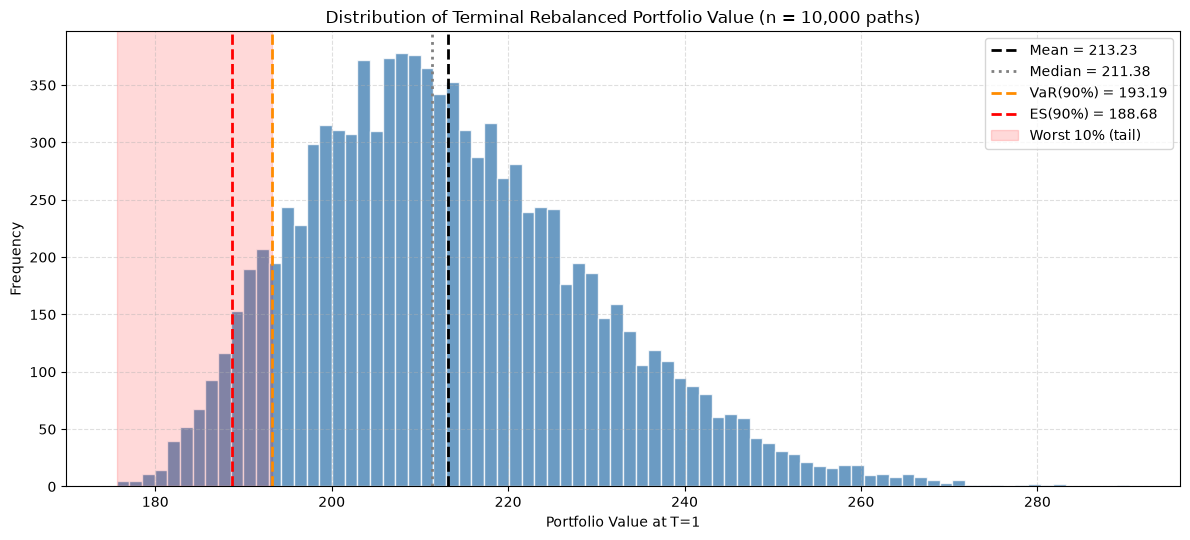

In [7]:
Port_S = np.full((n_paths, n_steps+1), MM0, dtype=float)
Port_MM = np.full((n_paths, n_steps+1), MM0, dtype=float)

for t in range(n_steps):
    ret = S[:, t+1] / S[:, t]
    Port_S[:, t+1] = Port_S[:, t] * ret
    Port_MM[:, t+1] = Port_MM[:, t] * np.exp(r[:, t]*dt)
    W = Port_S[:, t+1] + Port_MM[:, t+1]
    Port_S[:, t+1] = 0.5 * W
    Port_MM[:, t+1] = 0.5 * W

V_T_b = Port_S[:, -1] + Port_MM[:, -1] + P_T

mean_VT_b = np.mean(V_T_b)
median_VT_b = np.median(V_T_b)
std_VT_b = np.std(V_T_b, ddof=1)
VaR_90_b = np.quantile(V_T_b, 0.1)
ES_90_b = V_T_b[V_T_b <= VaR_90_b].mean()

risk_rows_b = [
    {'Metric': 'Mean', 'Portfolio Value': mean_VT_b},
    {'Metric': 'Median', 'Portfolio Value': median_VT_b},
    {'Metric': 'Std Dev', 'Portfolio Value': std_VT_b},
    {'Metric': 'VaR (90%)', 'Portfolio Value': VaR_90_b},
    {'Metric': 'ES (90%)', 'Portfolio Value': ES_90_b}]

df_risk_b = pd.DataFrame(risk_rows_b).style.format({'Value': '{:.4f}'}).hide(axis='index')
display(df_risk_b)

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.hist(V_T_b, bins=80, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(mean_VT_b, color='black', linestyle='--', linewidth=2, label=f'Mean = {mean_VT_b:.2f}')
ax.axvline(median_VT_b, color='gray', linestyle=':', linewidth=2, label=f'Median = {median_VT_b:.2f}')
ax.axvline(VaR_90_b, color='darkorange', linestyle='--', linewidth=2, label=f'VaR(90%) = {VaR_90_b:.2f}')
ax.axvline(ES_90_b, color='red', linestyle='--', linewidth=2, label=f'ES(90%) = {ES_90_b:.2f}')
ax.axvspan(V_T_b.min(), VaR_90_b, color='red', alpha=0.15, label='Worst 10% (tail)')
ax.set_xlabel('Portfolio Value at T=1')
ax.set_ylabel('Frequency')
ax.set_title(f'Distribution of Terminal Rebalanced Portfolio Value (n = {n_paths:,} paths)')
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

### 4.3 PCA on US Treasury Rates

Given Monthly US Treasury rates from `df_ust`: 826 month-end observations across 10 maturities (3M, 6M, 1Y, 2Y, 3Y, 5Y, 7Y, 10Y, 20Y, 30Y).


PCA is performed on the correlation matrix of monthly rate changes $Z(t)$ — a stationary transformation of the non-stationary rate levels $X(t)$, standardized so that each tenor contributes equally regardless of its absolute volatility.

Three change conventions are considered:

- Simple difference: $\;Z_i(t) = X_i(t) - X_i(t-1)$
- Log: $\;Z_i(t) = \ln\!\big(X_i(t)/X_i(t-1)\big)$
- Displaced log: $\;Z_i(t) = \ln\!\big((X_i(t) + \delta)/(X_i(t-1) + \delta)\big),\ \ \delta = 0.02$

Each tenor is standardized using its sample mean $\mu_T$ and sample standard deviation $\sigma_T$:

$$
\tilde Z(t) = \frac{Z(t) - \mu_T}{\sigma_T}
$$

The correlation matrix of the standardized changes is decomposed as

$$
\Sigma = \Gamma\,\Delta\,\Gamma^\top
$$

where $\Gamma = [\gamma_1 \mid \gamma_2 \mid \cdots \mid \gamma_K]$ holds the orthonormal eigenvectors (the principal component loadings) and $\Delta = \mathrm{diag}(\lambda_1, \lambda_2, \ldots, \lambda_K)$ holds the eigenvalues in descending order. Since $\Sigma$ is a correlation matrix, $\sum_k \lambda_k = K = 10$, and the share of total variance explained by component $i$ is

$$
\text{Percent explained by PC}(i) = \frac{\lambda_i}{V}, \qquad V = \sum_{k=1}^{K} \lambda_k
$$

Variance explained by the first three principal components (cumulative share)
$$
W_3 = \frac{\lambda_1 + \lambda_2 + \lambda_3}{V}
$$

For Treasury curves the loadings $\gamma_i$ typically align with three interpretable factors: $\gamma_1$ approximately constant across tenors (level shift), $\gamma_2$ monotonic with one sign change (slope), and $\gamma_3$ with two sign changes: positive at the wings and negative at the belly (curvature).

#### a) What percent of the variation is accounted for by the first 3 Principal Components?

In [8]:
rates = df_ust[maturity_cols]

dX_simple = rates.diff().dropna()
with np.errstate(divide='ignore'):
    dX_log = np.log(rates / rates.shift(1)).replace([np.inf, -np.inf], np.nan).dropna()
dX_disp_log = np.log((rates + 0.02) / (rates.shift(1) + 0.02)).dropna()


def pca_ust(dX):
    Z = (dX - dX.mean()) / dX.std(ddof=1)
    pca = PCA()
    pca.fit(Z)

    eigenvalues = pca.explained_variance_
    eigenvectors = pca.components_.T
    explained = pca.explained_variance_ratio_
    cumulative = np.cumsum(explained)
    pc_names = [f'PC{i+1}' for i in range(dX.shape[1])]

    summary = pd.DataFrame({
        'PC': pc_names,
        'Eigenvalue': eigenvalues,
        '% Explained': explained,
        'Cumulative %': cumulative,
    })
    loadings = pd.DataFrame(eigenvectors, index=dX.columns, columns=pc_names)
    return {
        'mu': dX.mean(),
        'sigma': dX.std(ddof=1),
        'summary': summary,
        'loadings': loadings,
        'n_obs': len(dX),
    }

model_simple = pca_ust(dX_simple)
display(Markdown("#### Correlation Matrix: Simple Differences"))
display(dX_simple.corr().style.format('{:.4f}').background_gradient(cmap='Reds').set_properties(**{'color': 'black'}))
display(Markdown("#### PC Loadings: Simple Differences"))
display(model_simple['loadings'].style.format('{:.4f}').background_gradient(cmap='RdBu_r', axis=None, vmin=-0.7, vmax=0.7).set_properties(**{'color': 'black'}))

display(Markdown("#### PCA Summary: Simple Differences"))
display(model_simple['summary'].style.format({
    'Eigenvalue': '{:.3f}',
    '% Explained': '{:.3%}',
    'Cumulative %': '{:.3%}',
}).hide(axis='index'))

cum_top3 = model_simple['summary']['Cumulative %'].iloc[2]
print(f"\nTop 3 PCs explain {cum_top3:.4%} of total variance")

#### Correlation Matrix: Simple Differences

,3M,6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
3M,1.0000,0.9614,0.8925,0.8113,0.7423,0.6702,0.6107,0.5695,0.5125,0.5100
6M,0.9614,1.0000,0.9545,0.8902,0.8284,0.7601,0.7050,0.6659,0.6068,0.6023
1Y,0.8925,0.9545,1.0000,0.9664,0.9182,0.8581,0.8027,0.7613,0.6971,0.6918
2Y,0.8113,0.8902,0.9664,1.0000,0.9808,0.9405,0.8949,0.8531,0.7791,0.7703
3Y,0.7423,0.8284,0.9182,0.9808,1.0000,0.9759,0.9393,0.9005,0.8239,0.8145
5Y,0.6702,0.7601,0.8581,0.9405,0.9759,1.0000,0.9823,0.9481,0.8801,0.8670
7Y,0.6107,0.7050,0.8027,0.8949,0.9393,0.9823,1.0000,0.9763,0.9213,0.9076
10Y,0.5695,0.6659,0.7613,0.8531,0.9005,0.9481,0.9763,1.0000,0.9531,0.9444
20Y,0.5125,0.6068,0.6971,0.7791,0.8239,0.8801,0.9213,0.9531,1.0000,0.9883
30Y,0.5100,0.6023,0.6918,0.7703,0.8145,0.8670,0.9076,0.9444,0.9883,1.0000


#### PC Loadings: Simple Differences

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
3M,0.2707,0.5268,0.3908,-0.4662,-0.4198,0.2727,0.1656,0.0266,0.0128,0.0165
6M,0.2974,0.4420,0.2345,0.0088,0.4592,-0.4808,-0.4615,0.0001,0.0372,-0.0682
1Y,0.3198,0.3077,-0.0754,0.4875,0.2726,0.1331,0.5449,-0.1492,-0.3059,0.2344
2Y,0.3337,0.1433,-0.3081,0.3345,-0.1217,0.2204,-0.0304,0.1967,0.5623,-0.4920
3Y,0.3356,0.0216,-0.3981,0.0991,-0.3649,0.0709,-0.4945,0.0588,-0.1482,0.5572
5Y,0.3345,-0.1155,-0.3462,-0.2471,-0.1941,-0.3368,0.1154,-0.1358,-0.5080,-0.5029
7Y,0.3293,-0.2190,-0.2033,-0.4038,0.1636,-0.3048,0.3610,-0.1064,0.5061,0.3489
10Y,0.3230,-0.2893,0.0134,-0.3060,0.5138,0.6164,-0.1993,0.0430,-0.1593,-0.0850
20Y,0.3073,-0.3652,0.4044,0.1765,-0.1094,-0.1918,0.1314,0.7039,-0.1158,0.0509
30Y,0.3047,-0.3647,0.4565,0.2726,-0.2242,0.0070,-0.1287,-0.6386,0.1170,-0.0552


#### PCA Summary: Simple Differences

PC,Eigenvalue,% Explained,Cumulative %
PC1,8.437,84.372%,84.372%
PC2,1.157,11.573%,95.945%
PC3,0.243,2.432%,98.377%
PC4,0.075,0.747%,99.124%
PC5,0.030,0.299%,99.423%
PC6,0.019,0.191%,99.614%
PC7,0.015,0.155%,99.769%
PC8,0.011,0.107%,99.876%
PC9,0.007,0.073%,99.949%
PC10,0.005,0.051%,100.000%



Top 3 PCs explain 98.3772% of total variance


#### Optional specifications: log and displaced log differences

The same PCA pipeline re-run on log differences $\ln(x_t / x_{t-1})$ and on displaced log differences $\ln[(x_t + 0.02) / (x_{t-1} + 0.02)]$, where the displacement keeps the transform well defined when short rates sit near zero. Variance shares and loadings are compared against the simple-difference base case.

#### PCA Summary: Log Differences

PC,Eigenvalue,% Explained,Cumulative %
PC1,7.1391,71.3910%,71.3910%
PC2,1.6328,16.3276%,87.7186%
PC3,0.6421,6.4209%,94.1396%
PC4,0.3345,3.3448%,97.4844%
PC5,0.1268,1.2683%,98.7527%
PC6,0.0716,0.7158%,99.4686%
PC7,0.0234,0.2339%,99.7025%
PC8,0.0121,0.1207%,99.8231%
PC9,0.0113,0.1133%,99.9364%
PC10,0.0064,0.0636%,100.0000%


#### PCA Summary: Displaced Log Differences

PC,Eigenvalue,% Explained,Cumulative %
PC1,7.8703,78.7028%,78.7028%
PC2,1.5293,15.2929%,93.9958%
PC3,0.3700,3.6998%,97.6955%
PC4,0.1139,1.1393%,98.8348%
PC5,0.0487,0.4868%,99.3216%
PC6,0.0231,0.2306%,99.5522%
PC7,0.0186,0.1856%,99.7378%
PC8,0.0113,0.1130%,99.8508%
PC9,0.0082,0.0821%,99.9329%
PC10,0.0067,0.0671%,100.0000%


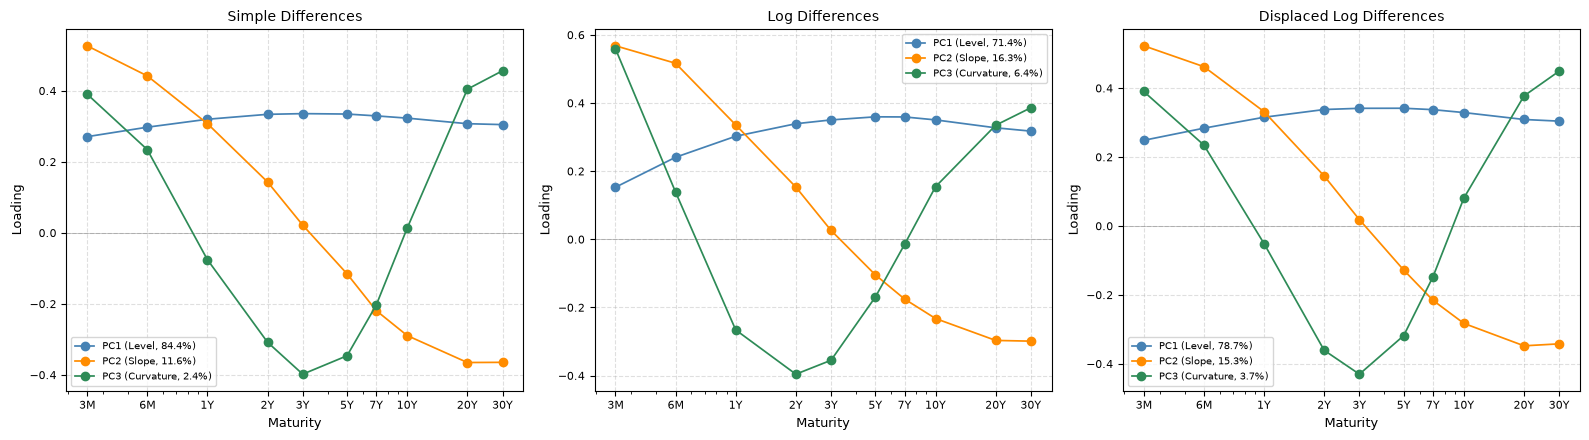

In [9]:
model_log = pca_ust(dX_log)
model_disp_log = pca_ust(dX_disp_log)

display(Markdown("#### PCA Summary: Log Differences"))
display(model_log['summary'].style.format({
    'Eigenvalue': '{:.4f}',
    '% Explained': '{:.4%}',
    'Cumulative %': '{:.4%}',
}).hide(axis='index'))

display(Markdown("#### PCA Summary: Displaced Log Differences"))
display(model_disp_log['summary'].style.format({
    'Eigenvalue': '{:.4f}',
    '% Explained': '{:.4%}',
    'Cumulative %': '{:.4%}',
}).hide(axis='index'))

mat_years = [0.25, 0.5, 1, 2, 3, 5, 7, 10, 20, 30]
colors = ['steelblue', 'darkorange', 'seagreen']

specs = {
    'Simple Differences': model_simple,
    'Log Differences': model_log,
    'Displaced Log Differences': model_disp_log,
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (name, model) in zip(axes, specs.items()):
    explained = model['summary']['% Explained'].values
    loadings = model['loadings']
    pc_labels = [f'PC1 (Level, {explained[0]*100:.1f}%)',
                 f'PC2 (Slope, {explained[1]*100:.1f}%)',
                 f'PC3 (Curvature, {explained[2]*100:.1f}%)']
    ax.axhline(0, color='black', linewidth=0.5, alpha=0.3)
    for k, (color, label) in enumerate(zip(colors, pc_labels)):
        ax.plot(mat_years, loadings[f'PC{k+1}'].values,
                color=color, linewidth=1.25, marker='o', markersize=6, label=label)
    ax.set_xscale('log')
    ax.set_xticks(mat_years)
    ax.set_xticklabels(maturity_cols, fontsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.set_xlabel('Maturity', fontsize=9)
    ax.set_ylabel('Loading', fontsize=9)
    ax.set_title(f'{name}', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc='best', fontsize=7)
plt.tight_layout()
plt.show()


#### b) 2-standard-deviation confidence interval for PC1

A $\pm 2\sigma$ stress on the first principal component fixes the PC1 score at its $\alpha$-percentile under normality and zeroes out PC2, PC3, …, isolating a pure level shift. Translating back to rate-level units at tenor $k$:

$$
X_k^{\text{shocked}} = X_k^{(0)} + \mu_{T,k} + \sigma_{T,k}\,\gamma_{1,k}\,\sqrt{\lambda_1}\,\Phi^{-1}(\alpha)\,\sqrt{\Delta t}
$$

where $X_k^{(0)}$ is the most recent observed rate at tenor $k$, $\mu_{T,k}$ and $\sigma_{T,k}$ are the historical mean and standard deviation of changes for that tenor, $\gamma_{1,k}$ is the PC1 loading, $\lambda_1$ is the PC1 eigenvalue, $\Phi^{-1}(\alpha)$ is the standard-normal quantile, and $\Delta t$ scales the shock to the desired horizon.

For a $\pm 2\sigma$ band, $\alpha$ is chosen so that $\Phi^{-1}(\alpha) = 2$. The horizon enters through $\sqrt{\Delta t}$, with $\Delta t = 1$ for a 1-month horizon (matching the PCA frequency) and $\Delta t = 12$ for a 12-month horizon under the i.i.d. assumption $\sigma_{12} = \sigma_1\sqrt{12}$.

The output is a shocked yield curve (10 rates) for each $\pm$ direction at each horizon, displayed alongside the initial curve.

**1-month 2-std PC1 confidence interval (Monthly Simple Differences)**

,3M,6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
+2 std,0.9082%,1.2399%,1.6083%,1.9690%,2.1322%,2.3124%,2.3820%,2.3626%,2.6635%,2.5778%
Initial,0.2200%,0.4900%,0.7800%,1.1800%,1.3900%,1.6200%,1.7500%,1.7900%,2.1700%,2.1100%
-2 std,-0.4729%,-0.2642%,-0.0521%,0.3881%,0.6451%,0.9252%,1.1156%,1.2149%,1.6743%,1.6399%


**12-month 2-std PC1 confidence interval (Monthly Simple Differences)**

,3M,6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
+2 std,2.5835%,3.0695%,3.6330%,3.9003%,3.9494%,4.0082%,3.9292%,3.7626%,3.8703%,3.7202%
Initial,0.2200%,0.4900%,0.7800%,1.1800%,1.3900%,1.6200%,1.7500%,1.7900%,2.1700%,2.1100%
-2 std,-2.2008%,-2.1410%,-2.1189%,-1.5761%,-1.2020%,-0.7973%,-0.4577%,-0.2129%,0.4433%,0.4713%


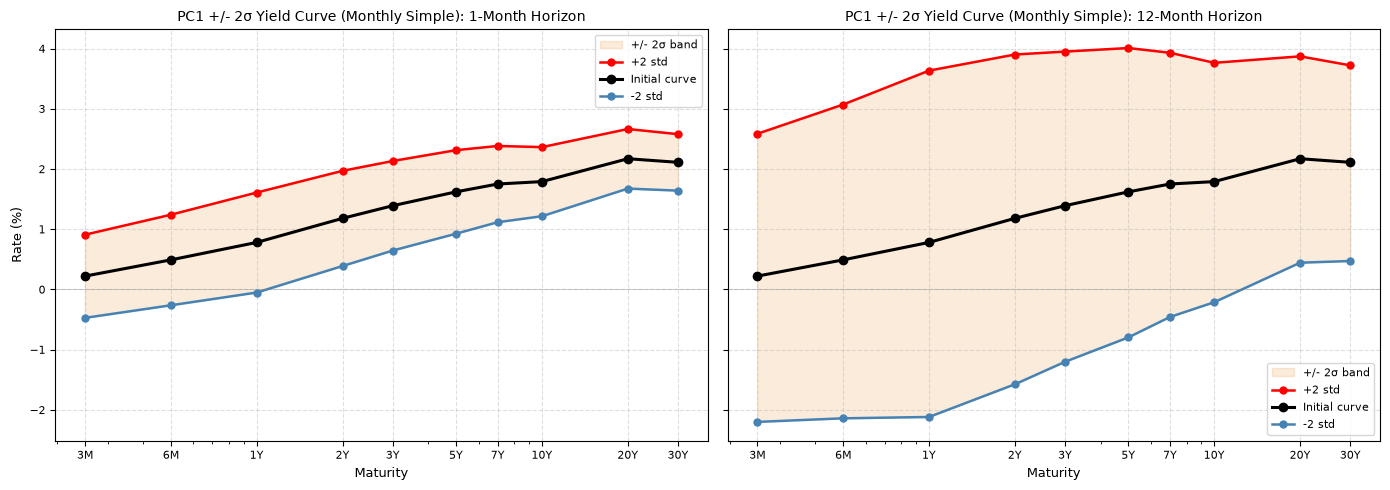

**1-month 2-std PC1 confidence interval (Monthly Log Differences)**

,3M,6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
+2 std,0.276%,0.605%,0.968%,1.462%,1.707%,1.929%,2.022%,2.021%,2.374%,2.289%
Initial,0.220%,0.490%,0.780%,1.180%,1.390%,1.620%,1.750%,1.790%,2.170%,2.110%
-2 std,0.174%,0.396%,0.627%,0.951%,1.130%,1.359%,1.513%,1.584%,1.982%,1.943%


**12-month 2-std PC1 confidence interval (Monthly Log Differences)**

,3M,6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
+2 std,0.473%,1.002%,1.630%,2.459%,2.818%,2.951%,2.876%,2.711%,2.950%,2.788%
Initial,0.220%,0.490%,0.780%,1.180%,1.390%,1.620%,1.750%,1.790%,2.170%,2.110%
-2 std,0.096%,0.230%,0.363%,0.554%,0.674%,0.877%,1.052%,1.167%,1.581%,1.579%


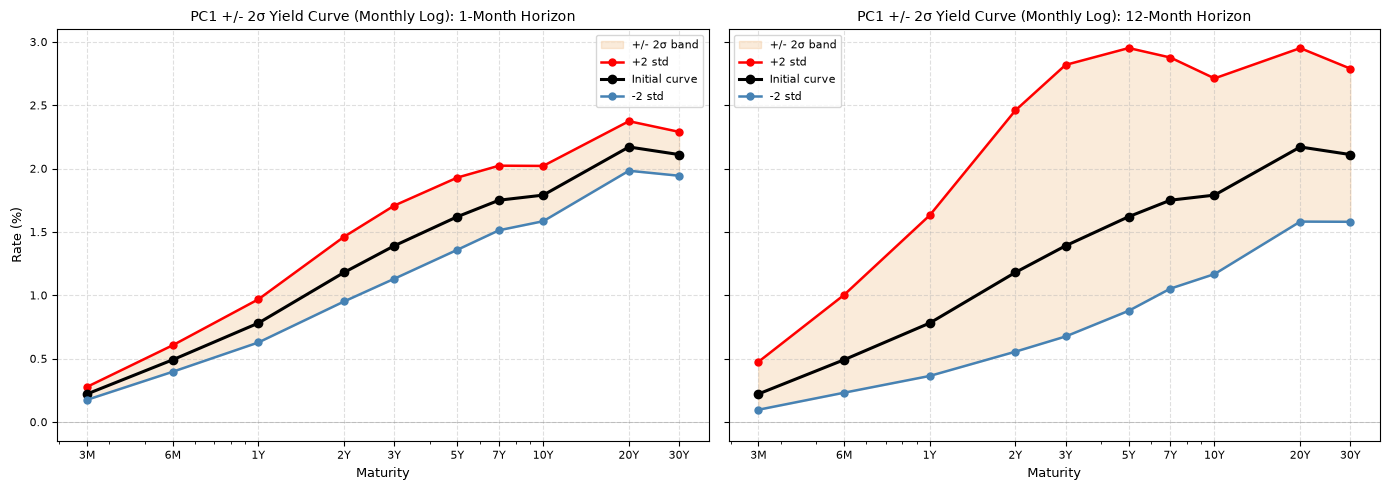

In [10]:
def PC1_CI(model, X0, dt, spec='simple', z=2):
    mu = model['mu']
    sigma = model['sigma']
    gamma1 = model['loadings']['PC1']
    lambda1 = model['summary']['Eigenvalue'].iloc[0]
    drift = mu * dt
    shock = sigma * gamma1 * np.sqrt(lambda1) * np.sqrt(dt)
    if spec == 'simple':
        X_up = X0 + drift + shock * z
        X_dn = X0 + drift - shock * z
    elif spec == 'log':
        X_up = X0 * np.exp(drift + shock * z)
        X_dn = X0 * np.exp(drift - shock * z)
    return pd.DataFrame({ f'+{z:.0f} std': X_up, 'Initial': X0, f'-{z:.0f} std': X_dn})

X0 = rates.iloc[-1]

CI_1m_simple = PC1_CI(model_simple, X0, dt=1)
CI_12m_simple = PC1_CI(model_simple, X0, dt=12)

display(Markdown("**1-month 2-std PC1 confidence interval (Monthly Simple Differences)**"))
display(CI_1m_simple.T.style.format('{:.4%}'))

display(Markdown("**12-month 2-std PC1 confidence interval (Monthly Simple Differences)**"))
display(CI_12m_simple.T.style.format('{:.4%}'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, band, title in [(axes[0], CI_1m_simple, '1-Month Horizon'), (axes[1], CI_12m_simple, '12-Month Horizon')]:
    ax.fill_between(mat_years, band['-2 std']*100, band['+2 std']*100, color='#E89B47', alpha=0.2, label='+/- 2σ band')
    ax.plot(mat_years, band['+2 std']*100, color='red', linewidth=1.8, marker='o', markersize=5, label='+2 std')
    ax.plot(mat_years, band['Initial']*100, color='black', linewidth=2.2, marker='o', markersize=6, label='Initial curve')
    ax.plot(mat_years, band['-2 std']*100, color='steelblue', linewidth=1.8, marker='o', markersize=5, label='-2 std')
    ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
    ax.set_xscale('log')
    ax.set_xticks(mat_years)
    ax.set_xticklabels(maturity_cols, fontsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.set_xlabel('Maturity', fontsize=9)
    ax.set_title(f'PC1 +/- 2σ Yield Curve (Monthly Simple): {title}', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc='best', fontsize=8)
axes[0].set_ylabel('Rate (%)', fontsize=9)
plt.tight_layout()
plt.show()

CI_1m_log = PC1_CI(model_log, X0, dt=1, spec='log')
CI_12m_log = PC1_CI(model_log, X0, dt=12, spec='log')

display(Markdown("**1-month 2-std PC1 confidence interval (Monthly Log Differences)**"))
display(CI_1m_log.T.style.format('{:.3%}'))

display(Markdown("**12-month 2-std PC1 confidence interval (Monthly Log Differences)**"))
display(CI_12m_log.T.style.format('{:.3%}'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, band, title in [(axes[0], CI_1m_log, '1-Month Horizon'), (axes[1], CI_12m_log, '12-Month Horizon')]:
    ax.fill_between(mat_years, band['-2 std']*100, band['+2 std']*100, color='#E89B47', alpha=0.2, label='+/- 2σ band')
    ax.plot(mat_years, band['+2 std']*100, color='red', linewidth=1.8, marker='o', markersize=5, label='+2 std')
    ax.plot(mat_years, band['Initial']*100, color='black', linewidth=2.2, marker='o', markersize=6, label='Initial curve')
    ax.plot(mat_years, band['-2 std']*100, color='steelblue', linewidth=1.8, marker='o', markersize=5, label='-2 std')
    ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
    ax.set_xscale('log')
    ax.set_xticks(mat_years)
    ax.set_xticklabels(maturity_cols, fontsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.set_xlabel('Maturity', fontsize=9)
    ax.set_title(f'PC1 +/- 2σ Yield Curve (Monthly Log): {title}', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc='best', fontsize=8)
axes[0].set_ylabel('Rate (%)', fontsize=9)
plt.tight_layout()
plt.show()

#### c) Redo using annual changes and compare your 12-month confidence intervals?

Annual changes are computed as **rolling 12-month differences**, $\Delta x_{t} = x_t - x_{t-12}$, taken at every month-end (overlapping windows). This preserves $n - 12$ observations



#### PCA Summary: Annual Simple Differences

PC,Eigenvalue,% Explained,Cumulative %
PC1,8.834,88.336%,88.336%
PC2,1.016,10.158%,98.494%
PC3,0.109,1.090%,99.585%
PC4,0.020,0.199%,99.784%
PC5,0.007,0.069%,99.853%
PC6,0.005,0.051%,99.903%
PC7,0.004,0.043%,99.946%
PC8,0.003,0.028%,99.975%
PC9,0.001,0.014%,99.989%
PC10,0.001,0.011%,100.000%


#### PCA Summary: Annual Log Differences

PC,Eigenvalue,% Explained,Cumulative %
PC1,7.589,75.892%,75.892%
PC2,1.884,18.843%,94.735%
PC3,0.386,3.857%,98.592%
PC4,0.094,0.945%,99.536%
PC5,0.024,0.237%,99.774%
PC6,0.008,0.083%,99.856%
PC7,0.006,0.064%,99.920%
PC8,0.005,0.048%,99.969%
PC9,0.002,0.017%,99.986%
PC10,0.001,0.014%,100.000%


**1-month 2-std PC1 confidence interval (Annual Simple Differences)**

,3M,6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
+2 std,1.025%,1.317%,1.645%,2.004%,2.168%,2.331%,2.400%,2.391%,2.698%,2.614%
Initial,0.220%,0.490%,0.780%,1.180%,1.390%,1.620%,1.750%,1.790%,2.170%,2.110%
-2 std,-0.589%,-0.342%,-0.089%,0.351%,0.607%,0.905%,1.097%,1.186%,1.640%,1.604%


**12-month 2-std PC1 confidence interval (Annual Simple Differences)**

,3M,6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
+2 std,2.990%,3.339%,3.758%,4.017%,4.069%,4.068%,3.987%,3.860%,3.990%,3.845%
Initial,0.220%,0.490%,0.780%,1.180%,1.390%,1.620%,1.750%,1.790%,2.170%,2.110%
-2 std,-2.598%,-2.408%,-2.250%,-1.708%,-1.339%,-0.873%,-0.527%,-0.316%,0.323%,0.348%


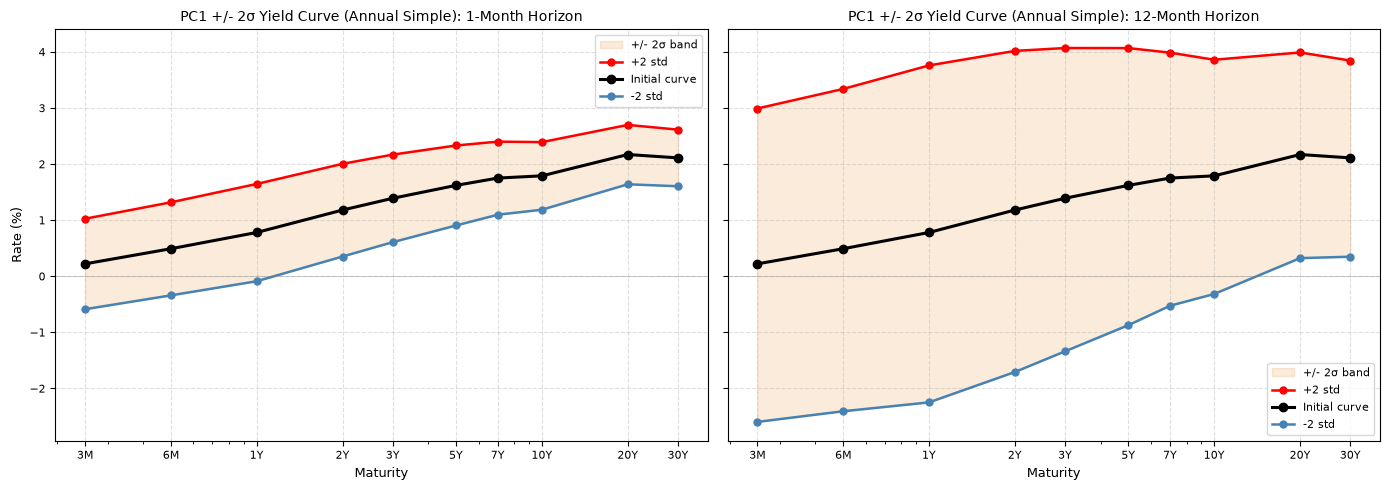

**1-month 2-std PC1 confidence interval (Annual Log Differences)**

,3M,6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
+2 std,0.295%,0.642%,1.014%,1.522%,1.766%,1.966%,2.038%,2.030%,2.371%,2.283%
Initial,0.220%,0.490%,0.780%,1.180%,1.390%,1.620%,1.750%,1.790%,2.170%,2.110%
-2 std,0.163%,0.371%,0.595%,0.910%,1.090%,1.332%,1.500%,1.576%,1.984%,1.949%


**12-month 2-std PC1 confidence interval (Annual Log Differences)**

,3M,6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
+2 std,0.580%,1.207%,1.880%,2.793%,3.138%,3.137%,2.948%,2.752%,2.939%,2.762%
Initial,0.220%,0.490%,0.780%,1.180%,1.390%,1.620%,1.750%,1.790%,2.170%,2.110%
-2 std,0.074%,0.180%,0.297%,0.470%,0.590%,0.814%,1.018%,1.145%,1.586%,1.596%


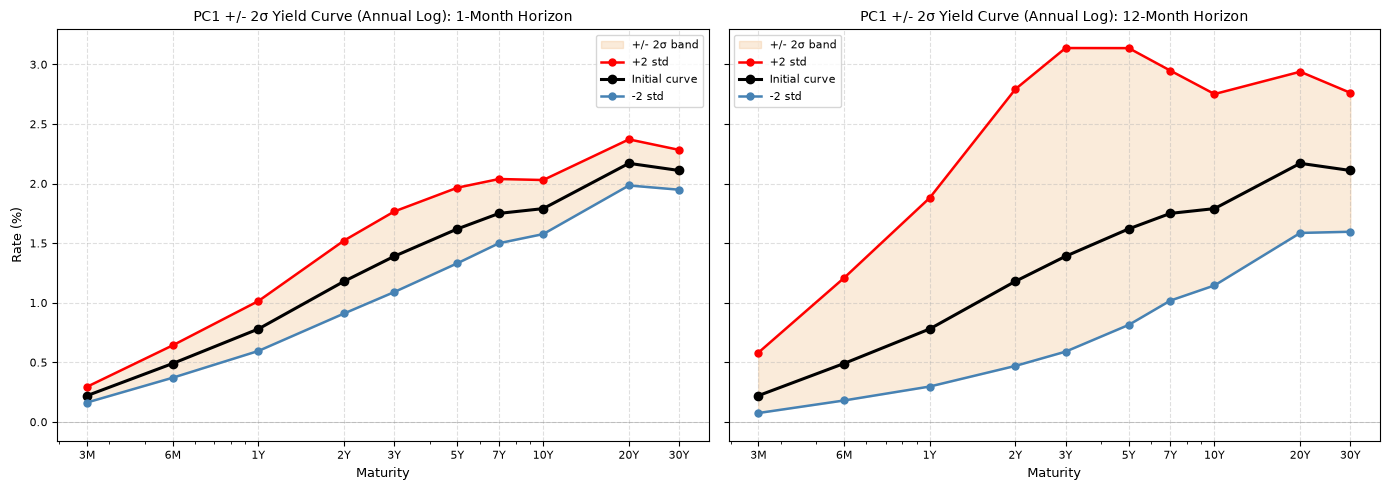

In [11]:
dX_simple_ann = (rates - rates.shift(12)).dropna()
with np.errstate(divide='ignore'):
    dX_log_ann = np.log(rates / rates.shift(12)).replace([np.inf, -np.inf], np.nan).dropna()

model_simple_ann = pca_ust(dX_simple_ann)
model_log_ann = pca_ust(dX_log_ann)

display(Markdown("#### PCA Summary: Annual Simple Differences"))
display(model_simple_ann['summary'].style.format({
    'Eigenvalue': '{:.3f}',
    '% Explained': '{:.3%}',
    'Cumulative %': '{:.3%}',
}).hide(axis='index'))

display(Markdown("#### PCA Summary: Annual Log Differences"))
display(model_log_ann['summary'].style.format({
    'Eigenvalue': '{:.3f}',
    '% Explained': '{:.3%}',
    'Cumulative %': '{:.3%}',
}).hide(axis='index'))

X0 = rates.iloc[-1]

CI_1m_simple_ann = PC1_CI(model_simple_ann, X0, dt=1/12)
CI_12m_simple_ann = PC1_CI(model_simple_ann, X0, dt=1)

display(Markdown("**1-month 2-std PC1 confidence interval (Annual Simple Differences)**"))
display(CI_1m_simple_ann.T.style.format('{:.3%}'))

display(Markdown("**12-month 2-std PC1 confidence interval (Annual Simple Differences)**"))
display(CI_12m_simple_ann.T.style.format('{:.3%}'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, band, title in [(axes[0], CI_1m_simple_ann, '1-Month Horizon'), (axes[1], CI_12m_simple_ann, '12-Month Horizon')]:
    ax.fill_between(mat_years, band['-2 std']*100, band['+2 std']*100, color='#E89B47', alpha=0.2, label='+/- 2σ band')
    ax.plot(mat_years, band['+2 std']*100, color='red', linewidth=1.8, marker='o', markersize=5, label='+2 std')
    ax.plot(mat_years, band['Initial']*100, color='black', linewidth=2.2, marker='o', markersize=6, label='Initial curve')
    ax.plot(mat_years, band['-2 std']*100, color='steelblue', linewidth=1.8, marker='o', markersize=5, label='-2 std')
    ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
    ax.set_xscale('log')
    ax.set_xticks(mat_years)
    ax.set_xticklabels(maturity_cols, fontsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.set_xlabel('Maturity', fontsize=9)
    ax.set_title(f'PC1 +/- 2σ Yield Curve (Annual Simple): {title}', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc='best', fontsize=8)
axes[0].set_ylabel('Rate (%)', fontsize=9)
plt.tight_layout()
plt.show()

CI_1m_log_ann = PC1_CI(model_log_ann, X0, dt=1/12,spec='log')
CI_12m_log_ann = PC1_CI(model_log_ann, X0, dt=1,spec='log')

display(Markdown("**1-month 2-std PC1 confidence interval (Annual Log Differences)**"))
display(CI_1m_log_ann.T.style.format('{:.3%}'))

display(Markdown("**12-month 2-std PC1 confidence interval (Annual Log Differences)**"))
display(CI_12m_log_ann.T.style.format('{:.3%}'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, band, title in [(axes[0], CI_1m_log_ann, '1-Month Horizon'), (axes[1], CI_12m_log_ann, '12-Month Horizon')]:
    ax.fill_between(mat_years, band['-2 std']*100, band['+2 std']*100, color='#E89B47', alpha=0.2, label='+/- 2σ band')
    ax.plot(mat_years, band['+2 std']*100, color='red', linewidth=1.8, marker='o', markersize=5, label='+2 std')
    ax.plot(mat_years, band['Initial']*100, color='black', linewidth=2.2, marker='o', markersize=6, label='Initial curve')
    ax.plot(mat_years, band['-2 std']*100, color='steelblue', linewidth=1.8, marker='o', markersize=5, label='-2 std')
    ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
    ax.set_xscale('log')
    ax.set_xticks(mat_years)
    ax.set_xticklabels(maturity_cols, fontsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.set_xlabel('Maturity', fontsize=9)
    ax.set_title(f'PC1 +/- 2σ Yield Curve (Annual Log): {title}', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc='best', fontsize=8)
axes[0].set_ylabel('Rate (%)', fontsize=9)
plt.tight_layout()
plt.show()


**12-month CI width comparison (Simple Differences)**

,PC1 CI via Monthly dif. (bps),PC1 CI via Annual dif. (bps),Difference (bps),Ratio
3M,478.4,558.8,+80.4,1.168
6M,521.1,574.7,+53.6,1.103
1Y,575.2,600.8,+25.6,1.045
2Y,547.6,572.5,+24.9,1.045
3Y,515.1,540.8,+25.6,1.050
5Y,480.6,494.0,+13.5,1.028
7Y,438.7,451.3,+12.6,1.029
10Y,397.5,417.6,+20.1,1.051
20Y,342.7,366.7,+24.0,1.070
30Y,324.9,349.7,+24.8,1.076


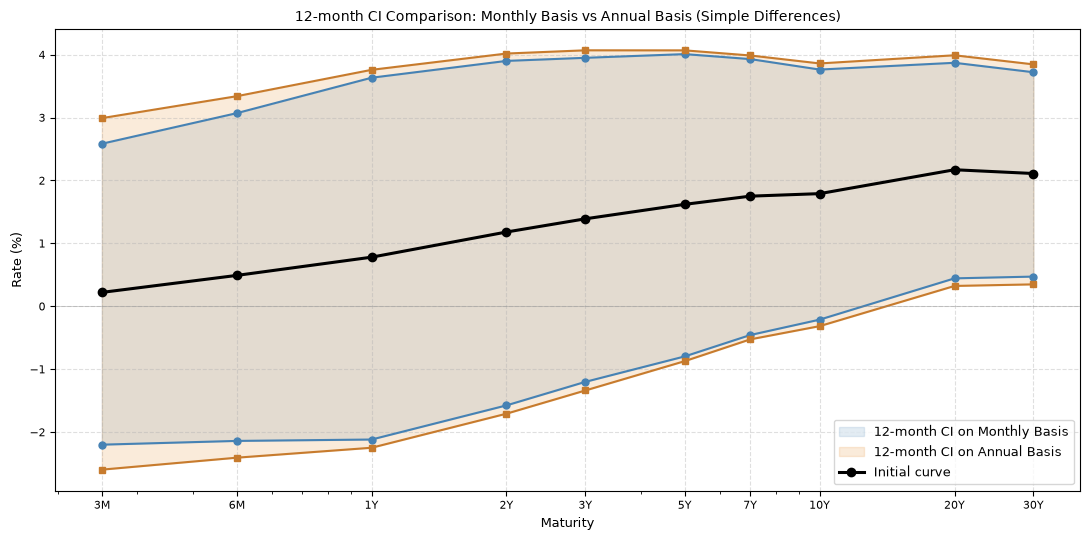

In [12]:
X0 = rates.iloc[-1]
ci_monthly = PC1_CI(model_simple, X0, dt=12)
ci_annual = PC1_CI(model_simple_ann, X0, dt=1)

width_monthly = ci_monthly['+2 std'] - ci_monthly['-2 std']
width_annual = ci_annual['+2 std'] - ci_annual['-2 std']

compare = pd.DataFrame({
    'PC1 CI via Monthly dif. (bps)': width_monthly * 10000,
    'PC1 CI via Annual dif. (bps)': width_annual * 10000,
    'Difference (bps)': (width_annual - width_monthly) * 10000,
    'Ratio': width_annual / width_monthly,
})

display(Markdown("**12-month CI width comparison (Simple Differences)**"))
display(compare.style.format({
    'PC1 CI via Monthly dif. (bps)': '{:.1f}',
    'PC1 CI via Annual dif. (bps)': '{:.1f}',
    'Difference (bps)': '{:+.1f}',
    'Ratio': '{:.3f}',
}))

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.fill_between(mat_years, ci_monthly['-2 std']*100, ci_monthly['+2 std']*100, color='steelblue', alpha=0.15, label='12-month CI on Monthly Basis')
ax.fill_between(mat_years, ci_annual['-2 std']*100, ci_annual['+2 std']*100, color='#E89B47', alpha=0.20, label='12-month CI on Annual Basis')

ax.plot(mat_years, ci_monthly['+2 std']*100, color='steelblue', linewidth=1.5, marker='o', markersize=5)
ax.plot(mat_years, ci_monthly['-2 std']*100, color='steelblue', linewidth=1.5, marker='o', markersize=5)
ax.plot(mat_years, ci_annual['+2 std']*100, color='#C77B2D', linewidth=1.5, marker='s', markersize=5)
ax.plot(mat_years, ci_annual['-2 std']*100, color='#C77B2D', linewidth=1.5, marker='s', markersize=5)

ax.plot(mat_years, X0*100, color='black', linewidth=2.2, marker='o', markersize=6, label='Initial curve')
ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)

ax.set_xscale('log')
ax.set_xticks(mat_years)
ax.set_xticklabels(maturity_cols, fontsize=8)
ax.tick_params(axis='y', labelsize=8)
ax.set_xlabel('Maturity', fontsize=9)
ax.set_ylabel('Rate (%)', fontsize=9)
ax.set_title('12-month CI Comparison: Monthly Basis vs Annual Basis (Simple Differences)', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(loc='best', fontsize=9)

plt.tight_layout()
plt.show()

The annual-direct CI is wider than the monthly-scaled CI at every maturity, with the largest gap at the front of the curve (3M: 1.17 times) and the smallest in the mid range (5Y: 1.03×). This reflects positive autocorrelation in monthly rate changes,  which the i.i.d. $\sqrt{12}$ scaling fails to capture. The annual-basis estimate is the more honest 12-month risk measure since it measures the full-year variance directly rather than inferring it from independent monthly draws.

### 4.4 Real Option Valuation

A 3-year project receives one unit of cashflow at each year-end, with profit per unit
$$
\text{CF}(C) = 1.2\,C - 25
$$
where $C$ is the spot commodity price. Under the risk-neutral measure $C$ follows a mean-reverting process:
$$
d\ln(C) = [\theta(t) - 0.1\ln(C)]\,dt + 0.2\,dz
$$

Calibration targets and parameters:
| Quantity | Value |
|---|---|
| Spot price $C_0$ | \$ 20 |
| Year-1 futures $F_1$ | \$ 22 |
| Year-2 futures $F_2$ | \$ 23 |
| Year-3 futures $F_3$ | \$ 24 |
| Mean-reversion speed $a$ | 0.1 |
| Log-price volatility $\sigma$ | 0.2 |
| Risk-free rate $r$ | 4% |
| Time step $\Delta t$ | 1 year |
| Number of steps | 3 |

The tree is built in $\ln C$ space with grid spacing $\Delta R = \sigma\sqrt{3\Delta t}$ and truncation level $j_{\max} = \lceil 0.184/(a\Delta t) \rceil$. Each node's commodity price is $C_{t,j} = \exp(\alpha_t + j\,\Delta R)$, where the offsets $\alpha_t$ are calibrated sequentially to reprice the futures curve.

#### a) What is the value of the profits with no optionality?

Without flexibility, the project value is the sum of risk-neutral expected cashflows, discounted at $r$. On the calibrated tree this is computed by backward induction:
$$
V_{t,j} = \text{CF}(C_{t,j}) + e^{-r\Delta t}\left[p_u\,V_{t+1,j+1} + p_m\,V_{t+1,j} + p_d\,V_{t+1,j-1}\right]
$$
with terminal condition $V_{3,j} = \text{CF}(C_{3,j})$. The profits value is $V_{0,0}$ at the root node.

Tree is calibrated to reproduce $F(0,t)$ at every horizon, hence the no-optionality value is equivalent to
$
V_{0,0} = \sum_{t=1}^{3} e^{-rt}\bigl(1.2\,F(0,t) - 25\bigr)
$, but we will use trinomial to solve.


**Calibrated Trinomial Tree:**

Value of the profits: $7.1155


t,j,Price,CF,P(reach),pu,pm,pd,V
0,0,20.000,+0.000,1.000,0.167,0.667,0.167,+7.116
1,1,30.492,+11.590,0.167,0.122,0.657,0.222,+34.852
1,0,21.564,+0.877,0.667,0.167,0.667,0.167,+6.113
1,-1,15.251,-6.699,0.167,0.222,0.657,0.122,-14.867
2,2,44.350,+28.220,0.020,0.887,0.027,0.087,+54.173
2,1,31.365,+12.639,0.221,0.122,0.657,0.222,+25.323
2,0,22.182,+1.619,0.518,0.167,0.667,0.167,+4.472
2,-1,15.688,-6.175,0.221,0.222,0.657,0.122,-10.519
2,-2,11.095,-11.686,0.020,0.087,0.027,0.887,-21.245
3,2,45.679,+29.814,0.045,nan,nan,nan,+29.814


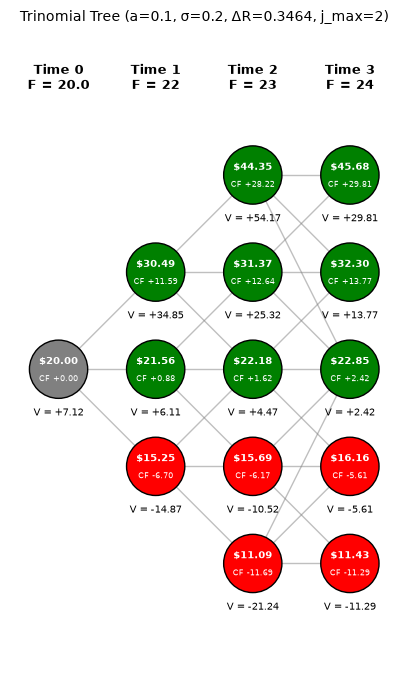

In [13]:
C0 = 20.0
r = 0.04
a = 0.10
sigma = 0.20
F = [22, 23, 24]
n_steps = 3
dt = 1.0

def get_branch_prob(j, j_max, a, dt):
    M = -a * j * dt
    if j == j_max:
        prob_up   = 7/6 + (M**2 + 3*M)/2
        prob_mid  = -1/3 - M**2 - 2*M
        prob_down = 1/6 + (M**2 + M)/2
    elif j == -j_max:
        prob_up   = 1/6 + (M**2 - M)/2
        prob_mid  = -1/3 - M**2 + 2*M
        prob_down = 7/6 + (M**2 - 3*M)/2
    else:
        prob_up   = 1/6 + (M**2 + M)/2
        prob_mid  = 2/3 - M**2
        prob_down = 1/6 + (M**2 - M)/2
    return prob_up, prob_mid, prob_down

def get_child_nodes(j, j_max):
    if j == j_max:
        return [j, j-1, j-2]
    elif j == -j_max:
        return [j+2, j+1, j]
    else:
        return [j+1, j, j-1]

def build_rich_tree(C0, F, sigma, a, dt, n_steps):
    DR = sigma * np.sqrt(3 * dt)
    j_max = int(np.ceil(0.184 / (a * dt)))

    tree = [{} for _ in range(n_steps + 1)]
    tree[0][0] = {
        'price': C0,
        'cf': 0.0,
        'prob_reach': 1.0
    }

    for t in range(1, n_steps + 1):
        P_reach_next = {}

        for j_prev, node_prev in tree[t-1].items():
            pu, pm, pd = get_branch_prob(j_prev, j_max, a, dt)
            cu, cm, cd = get_child_nodes(j_prev, j_max)

            node_prev['prob_up'] = pu
            node_prev['prob_mid'] = pm
            node_prev['prob_down'] = pd
            node_prev['child_up'] = cu
            node_prev['child_mid'] = cm
            node_prev['child_down'] = cd

            for child_j, branch_prob in zip([cu, cm, cd], [pu, pm, pd]):
                P_reach_next[child_j] = P_reach_next.get(child_j, 0.0) + node_prev['prob_reach'] * branch_prob

        js_array = np.array(list(P_reach_next.keys()))
        probs_array = np.array(list(P_reach_next.values()))

        def pricing_error(alpha_guess):
            return np.sum(probs_array * np.exp(alpha_guess + js_array * DR)) - F[t-1]

        alpha_t = brentq(pricing_error, -5, 10)

        for j, p_reach in P_reach_next.items():
            price = np.exp(alpha_t + j * DR)
            tree[t][j] = {
                'price': price,
                'cf': 1.2 * price - 25,
                'prob_reach': p_reach
            }

    return tree, j_max

tree, j_max = build_rich_tree(C0, F, sigma, a, dt, n_steps)

df = np.exp(-r * dt)

for j, node in tree[n_steps].items():
    node['V'] = node['cf']

for t in range(n_steps - 1, -1, -1):
    for j, node in tree[t].items():
        expected_future_value = (
            node['prob_up'] * tree[t+1][node['child_up']]['V'] +
            node['prob_mid'] * tree[t+1][node['child_mid']]['V'] +
            node['prob_down'] * tree[t+1][node['child_down']]['V']
        )

        current_cf = node['cf'] if t > 0 else 0
        node['V'] = current_cf + df * expected_future_value

project_value_tree = tree[0][0]['V']

rows = []
for t, layer in enumerate(tree):
    for j in sorted(layer.keys(), reverse=True):
        n = layer[j]
        rows.append({
            't': t,
            'j': j,
            'Price': n['price'],
            'CF': n['cf'],
            'P(reach)': n['prob_reach'],
            'pu': n.get('prob_up', np.nan),
            'pm': n.get('prob_mid', np.nan),
            'pd': n.get('prob_down', np.nan),
            'V': n['V'],
        })

df_tree = pd.DataFrame(rows)
display(Markdown("**Calibrated Trinomial Tree:**"))
print(f"Value of the profits: ${project_value_tree:.4f}")
display(df_tree.style.format({
    'Price': '{:.3f}',
    'CF': '{:+.3f}',
    'P(reach)': '{:.3f}',
    'pu': '{:.3f}',
    'pm': '{:.3f}',
    'pd': '{:.3f}',
    'V': '{:+.3f}',
}).hide(axis='index'))

fig, ax = plt.subplots(figsize=(5, 7))
for t in range(n_steps):
    for j, node in tree[t].items():
        cu, cm, cd = node['child_up'], node['child_mid'], node['child_down']
        for cj in [cu, cm, cd]:
            ax.plot([t, t+1], [j, cj], color='gray', linewidth=1, alpha=0.5, zorder=1)
for t, layer in enumerate(tree):
    for j, node in layer.items():
        if t == 0:
            node_color = 'gray'
        elif node['cf'] > 0:
            node_color = 'green'
        else:
            node_color = 'red'
        circle = plt.Circle((t, j), radius=0.3, color=node_color, zorder=3, ec='black', linewidth=1)
        ax.add_patch(circle)
        ax.text(t, j + 0.08, f"${node['price']:.2f}", ha='center', va='center', fontsize=7, color='white', fontweight='bold', zorder=4)
        ax.text(t, j - 0.1, f"CF {node['cf']:+.2f}", ha='center', va='center', fontsize=6, color='white', zorder=4)
        ax.text(t, j - 0.45, f"V = {node['V']:+.2f}", ha='center', va='center',
                fontsize=7, color='black', zorder=4)
for t in range(n_steps + 1):
    future_price = C0 if t == 0 else F[t-1]
    label = f"Time {t}\nF = {future_price}"
    ax.text(t, j_max + 1.0, label, ha='center', va='center', fontsize=9, fontweight='bold')

ax.set_xlim(-0.5, n_steps + 0.5)
ax.set_ylim(-j_max - 1.2, j_max + 1.5)
ax.set_aspect('equal')
ax.axis('off')
DR = sigma * np.sqrt(3 * dt)
ax.set_title(f'Trinomial Tree (a={a}, σ={sigma}, ΔR={DR:.4f}, j_max={j_max})', fontsize=10)
plt.tight_layout()
plt.show()

#### b) What is with the option to abandon at $t = 1$ or $t = 2$ for $5 ?

At each abandon-eligible node, the backward-induction rule becomes
$$
V_{t,j} = \max\!\Big(V_{t,j}^{\text{continue}},\ -5\Big)
$$
where the continuation value is the standard recursion from part (a):
$$
V_{t,j}^{\text{continue}} = \text{CF}(C_{t,j}) + e^{-r\Delta t}\!\left[p_u\,V_{t+1,j+1} + p_m\,V_{t+1,j} + p_d\,V_{t+1,j-1}\right]
$$

At nodes where abandonment is not available ($t = 0$ and $t = 3$) the value reduces to the continuation value. The tree, probabilities, and discount factor are unchanged from part (a); only the local update rule at $t \in \{1, 2\}$ differs.

The abandonment option value is the difference between the project value with the option to abandon and the project value with no flexibility (from part (a)):
$$
V_{\text{abandon option}} = V^{\text{(b)}}_{0,0} - V^{\text{(a)}}_{0,0} \ge 0
$$
The inequality holds because the firm is never forced to exercise — at worst the option goes unused and the value coincides with part (a).

In [14]:
abandon_payoff = -5
for j, node in tree[n_steps].items():
    node['V_b'] = node['cf']
    node['abandon'] = False

for t in range(n_steps - 1, -1, -1):
    for j, node in tree[t].items():
        EV = (node['prob_up'] * tree[t+1][node['child_up']]['V_b']
              + node['prob_mid'] * tree[t+1][node['child_mid']]['V_b']
              + node['prob_down'] * tree[t+1][node['child_down']]['V_b'])
        CV_future = df * EV
        cf_t = node['cf'] if t > 0 else 0

        if t in (1, 2) and abandon_payoff > CV_future:
            node['V_b'] = cf_t + abandon_payoff
            node['abandon'] = True
        else:
            node['V_b'] = cf_t + CV_future
            node['abandon'] = False

V_b = tree[0][0]['V_b']

rows = []
for t, layer in enumerate(tree):
    for j in sorted(layer.keys(), reverse=True):
        n = layer[j]
        rows.append({
            't': t, 'j': j,
            'Price': n['price'],
            'CF': n['cf'],
            'P(reach)': n['prob_reach'],
            'pu': n.get('prob_up', np.nan),
            'pm': n.get('prob_mid', np.nan),
            'pd': n.get('prob_down', np.nan),
            'V (no opt)': n['V'],
            'V (abandon)': n['V_b'],
            'Abandon?': 'yes' if n['abandon'] else 'no',
        })

df_tree = pd.DataFrame(rows)

display(Markdown("**Calibrated Trinomial Tree with Abandon Option**"))
display(df_tree.style.format({
    'Price': '{:.3f}', 'CF': '{:+.3f}', 'P(reach)': '{:.3f}',
    'pu': '{:.3f}', 'pm': '{:.3f}', 'pd': '{:.3f}',
    'V (no opt)': '{:+.3f}', 'V (abandon)': '{:+.3f}',
}, na_rep='—').hide(axis='index'))

print(f"Project value (with abandon): ${V_b:.4f}")

**Calibrated Trinomial Tree with Abandon Option**

t,j,Price,CF,P(reach),pu,pm,pd,V (no opt),V (abandon),Abandon?
0,0,20.000,+0.000,1.000,0.167,0.667,0.167,+7.116,+7.623,no
1,1,30.492,+11.590,0.167,0.122,0.657,0.222,+34.852,+34.852,no
1,0,21.564,+0.877,0.667,0.167,0.667,0.167,+6.113,+6.113,no
1,-1,15.251,-6.699,0.167,0.222,0.657,0.122,-14.867,-11.699,yes
2,2,44.350,+28.220,0.020,0.887,0.027,0.087,+54.173,+54.173,no
2,1,31.365,+12.639,0.221,0.122,0.657,0.222,+25.323,+25.323,no
2,0,22.182,+1.619,0.518,0.167,0.667,0.167,+4.472,+4.472,no
2,-1,15.688,-6.175,0.221,0.222,0.657,0.122,-10.519,-10.519,no
2,-2,11.095,-11.686,0.020,0.087,0.027,0.887,-21.245,-16.686,yes
3,2,45.679,+29.814,0.045,—,—,—,+29.814,+29.814,no


Project value (with abandon): $7.6228


#### c) What is the value of the profits if you can double production at time $t = 2$ for $10?

The expansion option is available only at $t = 2$. Exercising it costs  10 immediately and doubles the year-3 cashflow at every reachable child node. So at each $t = 2$ node the firm compares:

$$
V_{2,j} = \text{CF}(C_{2,j}) + \max\!\Big(V_{2,j}^{\text{continue}},\ V_{2,j}^{\text{expand}}\Big)
$$

with

$$
V_{2,j}^{\text{continue}} = e^{-r\Delta t}\!\sum_{k} p_k\,\text{CF}(C_{3,k})
$$
$$
V_{2,j}^{\text{expand}} = e^{-r\Delta t}\!\sum_{k} p_k\,\bigl[2 \cdot \text{CF}(C_{3,k})\bigr] - 10
$$

where the sum is over the three children $k \in \{j+1, j, j-1\}$ (or the truncated branches at the boundary). Outside $t = 2$, the rule reduces to the standard continuation as in part (a).

The expansion option value is the difference between the project value with the option to expand and the no-flexibility value from part (a):
$$
V_{\text{expand option}} = V^{\text{(c)}}_{0,0} - V^{\text{(a)}}_{0,0} \ge 0
$$



In [15]:
expand_cost = 10

for j, node in tree[n_steps].items():
    node['V_c'] = node['cf']
    node['expand'] = False

for t in range(n_steps - 1, -1, -1):
    for j, node in tree[t].items():
        EV = (node['prob_up'] * tree[t+1][node['child_up']]['V_c'] +
              node['prob_mid'] * tree[t+1][node['child_mid']]['V_c'] +
              node['prob_down'] * tree[t+1][node['child_down']]['V_c'])

        CV_future = df * EV
        cf_t = node['cf'] if t > 0 else 0
        if t == 2:
            CV_expand = df * (2 * EV) - expand_cost
            if CV_expand > CV_future:
                node['V_c'] = cf_t + CV_expand
                node['expand'] = True
            else:
                node['V_c'] = cf_t + CV_future
                node['expand'] = False
        else:
            node['V_c'] = cf_t + CV_future
            node['expand'] = False

V_c = tree[0][0]['V_c']

rows_c = []
for t, layer in enumerate(tree):
    for j in sorted(layer.keys(), reverse=True):
        n = layer[j]
        rows_c.append({
            't': t, 'j': j,
            'Price': n['price'],
            'CF': n['cf'],
            'P(reach)': n['prob_reach'],
            'pu': n.get('prob_up', np.nan),
            'pm': n.get('prob_mid', np.nan),
            'pd': n.get('prob_down', np.nan),
            'V (no opt)': n['V'],
            'V (expand)': n['V_c'],
            'Expand?': 'yes' if n['expand'] else 'no',
        })

df_tree_c = pd.DataFrame(rows_c)

display(Markdown("**Calibrated Trinomial Tree with Expansion Option**"))
display(df_tree_c.style.format({
    'Price': '{:.3f}', 'CF': '{:+.3f}', 'P(reach)': '{:.3f}',
    'pu': '{:.3f}', 'pm': '{:.3f}', 'pd': '{:.3f}',
    'V (no opt)': '{:+.3f}', 'V (expand)': '{:+.3f}',
}, na_rep='—').hide(axis='index'))

print(f"Project value (with expand): ${V_c:.4f}")

**Calibrated Trinomial Tree with Expansion Option**

t,j,Price,CF,P(reach),pu,pm,pd,V (no opt),V (expand),Expand?
0,0,20.000,+0.000,1.000,0.167,0.667,0.167,+7.116,+7.961,no
1,1,30.492,+11.590,0.167,0.122,0.657,0.222,+34.852,+38.411,no
1,0,21.564,+0.877,0.667,0.167,0.667,0.167,+6.113,+6.542,no
1,-1,15.251,-6.699,0.167,0.222,0.657,0.122,-14.867,-14.867,no
2,2,44.350,+28.220,0.020,0.887,0.027,0.087,+54.173,+70.126,yes
2,1,31.365,+12.639,0.221,0.122,0.657,0.222,+25.323,+28.008,yes
2,0,22.182,+1.619,0.518,0.167,0.667,0.167,+4.472,+4.472,no
2,-1,15.688,-6.175,0.221,0.222,0.657,0.122,-10.519,-10.519,no
2,-2,11.095,-11.686,0.020,0.087,0.027,0.887,-21.245,-21.245,no
3,2,45.679,+29.814,0.045,—,—,—,+29.814,+29.814,no


Project value (with expand): $7.9608
